In [13]:
import os
import random
import numpy as np
import tensorflow as tf
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

SEED = 1234

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

from project.loader import Loader
from project.CROP.models.crop2 import Crop2 
from project.CROP.models.crop3_estimation_correction import Crop3EstimationCorrection


dataset = "mnist"
inter=256
lat=64

data = Loader.data(dataset=dataset)
predictor = Loader.predictor(dataset=dataset)

x_train = data["x_train"]
x_train_1 = data["x_train_1"]
y_train = data["y_train"]
y_train_1 = data["y_train_1"]
ITERATIONS = 30

#c =Crop2(predictor=predictor,lat=lat,inter=inter,dataset=dataset)
c = Crop3EstimationCorrection(predictor=predictor,lat=lat,inter=inter,dataset=dataset)
def objective(trial):
    #bias    = trial.suggest_float("bias", 0, 2)
    #slope   = trial.suggest_float("slope", 5, 30)
    gamma   = trial.suggest_float("gamma", 0, 2)
    delta   = trial.suggest_float("delta", 0, 2)
    n_images = 1000

    try:

        # Selección de datos
        X0 = x_train[:n_images]
        Y0 = y_train[:n_images]

        X1 = x_train_1[:n_images]
        Y1 = y_train_1[:n_images]

        # Randomización independiente para (x_train, y_train)
        idx0 = np.random.permutation(len(X0))
        X0 = X0[idx0]
        Y0 = Y0[idx0]

        # Randomización independiente para (x_train_1, y_train_1)
        idx1 = np.random.permutation(len(X1))
        X1 = X1[idx1]
        Y1 = Y1[idx1]

        metrics = c.unmix(
            X0,
            X1,
            Y0,
            Y1,
            #params={'gamma':gamma}, #crop 2
            #params={'gamma': 1.0602623807869416,'delta':delta}, #msnit ssim crop2 -->crop3
            #params={'gamma': 0.7267875665823903, 'delta': delta}, #  crop2--> crop3
            #params={'gamma': 0.9256608959277062,'delta':delta}, #ssim fashion crop2-->crop3
            params={'gamma':gamma,'delta':delta}, #solocrop3            
            iterations=ITERATIONS,
            show_metrics=False
        )

        return float(metrics["ssim"][0])

    except Exception as e:
        print(f"Error: {e}")
        return float("-inf")  
    



Usando mnist como dataset


In [14]:
import optuna

# Creamos un estudio de minimización
study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials=100) 

# Mostramos los mejores resultados
print("\n📊 Mejores hiperparámetros encontrados:")
print(study.best_trials)

[I 2026-06-27 00:10:16,178] A new study created in memory with name: no-name-943156a3-52dd-4902-9435-08cb4c11b003
[I 2026-06-27 00:10:19,855] Trial 0 finished with value: 0.6611677408218384 and parameters: {'gamma': 1.6872856325668004, 'delta': 1.5622754651110495}. Best is trial 0 with value: 0.6611677408218384.
[I 2026-06-27 00:10:23,813] Trial 1 finished with value: 0.8049966096878052 and parameters: {'gamma': 0.4661388057507565, 'delta': 0.28212662421301604}. Best is trial 1 with value: 0.8049966096878052.
[I 2026-06-27 00:10:27,632] Trial 2 finished with value: 0.6208646297454834 and parameters: {'gamma': 0.6353143676406188, 'delta': 1.3248423277879176}. Best is trial 1 with value: 0.8049966096878052.
[I 2026-06-27 00:10:31,198] Trial 3 finished with value: 0.7576412558555603 and parameters: {'gamma': 0.8217423825877024, 'delta': 0.7007216892726285}. Best is trial 1 with value: 0.8049966096878052.
[I 2026-06-27 00:10:34,849] Trial 4 finished with value: 0.7764663100242615 and param


📊 Mejores hiperparámetros encontrados:
[FrozenTrial(number=92, state=1, values=[0.8209942579269409], datetime_start=datetime.datetime(2026, 6, 27, 0, 15, 10, 288526), datetime_complete=datetime.datetime(2026, 6, 27, 0, 15, 13, 307474), params={'gamma': 1.0507384749934656, 'delta': 0.03166310123273044}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'gamma': FloatDistribution(high=2.0, log=False, low=0.0, step=None), 'delta': FloatDistribution(high=2.0, log=False, low=0.0, step=None)}, trial_id=92, value=None)]


In [15]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 19.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [16]:
#optuna.visualization.plot_slice(study, params=['gamma'])
#optuna.visualization.plot_slice(study, params=['delta'])
optuna.visualization.plot_slice(study, params=['gamma','delta'])

#optuna.visualization.plot_slice(study, params=['bias','slope','gamma'])



ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'color': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
                                   14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25,
                                   26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37,
                                   38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49,
                                   50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61,
                                   62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73,
                                   74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
                                   86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97,
                                   98, 99],
                         'colorbar': {'title': {'text': 'Trial'}, 'x': 1.0, 'xpad': 40},
                         'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                                        'rgb(222,235,247)'], [0.25,
                                        'rgb(198,219,239)'], [0.375,
                                        'rgb(158,202,225)'], [0.5,
                                        'rgb(107,174,214)'], [0.625,
                                        'rgb(66,146,198)'], [0.75,
                                        'rgb(33,113,181)'], [0.875,
                                        'rgb(8,81,156)'], [1.0, 'rgb(8,48,107)']],
                         'line': {'color': 'Grey', 'width': 0.5},
                         'showscale': True},
              'mode': 'markers',
              'name': 'Feasible Trial',
              'showlegend': False,
              'type': 'scatter',
              'x': [1.5622754651110495, 0.28212662421301604, 1.3248423277879176,
                    0.7007216892726285, 0.6002776704258252, 1.411986403884993,
                    1.3968881884529583, 1.3189774308016429, 0.6748592676367673,
                    1.6837134149958761, 0.00754732991089857, 0.0437324294117086,
                    0.009403794820960987, 0.34719501310074563, 0.3319024259448165,
                    0.9186400854982941, 0.2979808262519399, 0.36086505609429803,
                    1.9395377840243684, 1.0355333277072913, 0.24363915303362327,
                    0.23587581267808008, 0.5076366986306842, 0.17662708689244,
                    0.1437707185591405, 0.8661677271876524, 0.1381134012030969,
                    0.5073752283445676, 0.07585892642862749, 0.12947743892848318,
                    1.11520043874769, 0.10800925942593241, 0.1356509807998632,
                    0.46804689287622003, 0.19086414847252892, 0.4135052032680089,
                    0.21691604905678188, 0.7716091019220749, 0.6043884352229915,
                    0.2443220230635416, 0.21957449074726448, 0.22579708094671963,
                    0.20479088744507004, 0.5782999759795553, 0.42042561676000156,
                    0.2909033043599064, 0.0060422393877020975, 0.727104080532728,
                    1.2120830686789272, 0.38183832656458194, 0.6382479930633341,
                    0.22866029098082072, 0.21248472898030998, 0.30837882342178036,
                    0.4627994640304183, 1.5980232466256439, 0.06573625739923594,
                    0.06965262377197168, 0.06032094832000065, 0.052416908735341605,
                    0.05315592050873494, 0.005017043318952481,
                    0.005643491554356145, 0.07110861321732605, 0.0791617514267243,
                    0.1602412841223902, 0.0021217484432910633, 0.11340334733175339,
                    0.09821854916595657, 0.30891977539741894, 0.014032788091845605,
                    0.137205178354485, 0.11464304488582229, 0.1683294366312,
                    0.0030510826983768564, 0.2731240075686385, 0.12884894795734417,
                    0.014798239623033924, 0.004501882372734828,
                    0.07577446217656825, 1.827711611191234, 0.15371380463211118,
                    0.10344984769617244, 0.03925964746314282, 0.26368017955170797,
                    0.09020452288796169, 0.18264553

# Validación


Usando mnist como dataset
Run 1/10


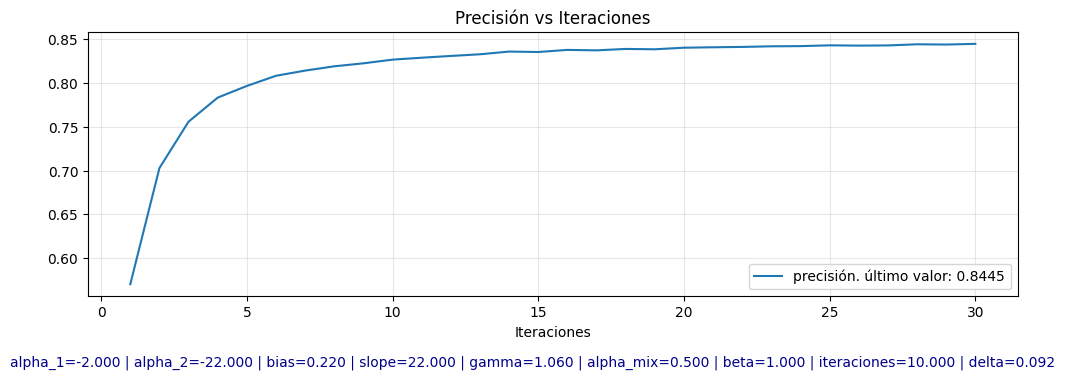

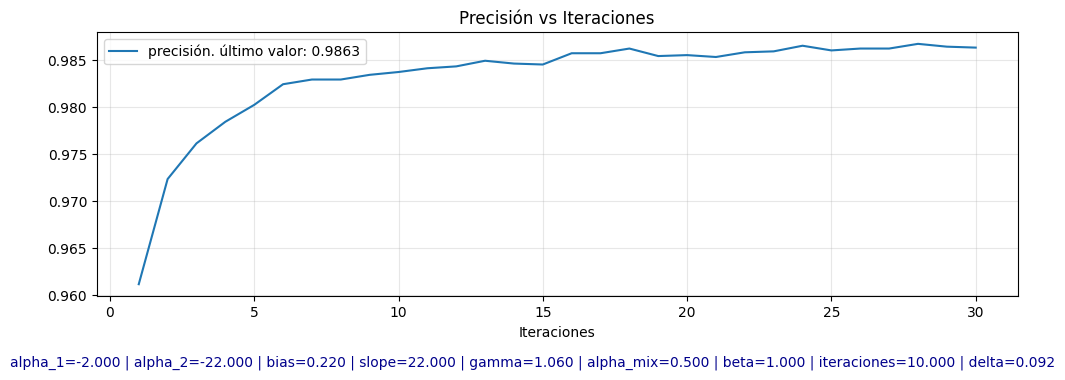

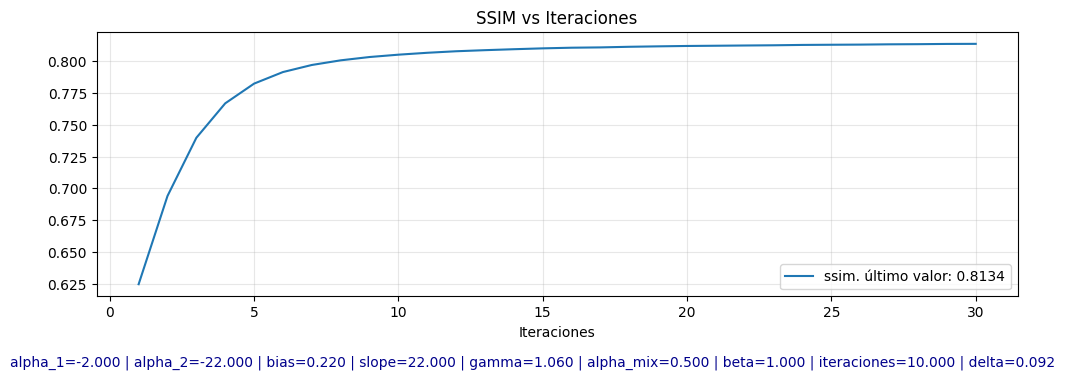

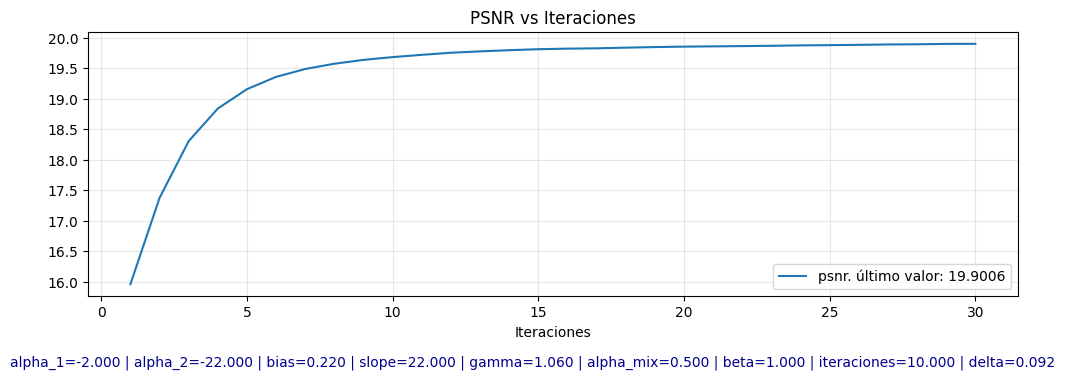


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.060
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.092

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.901  std:3.235
mask_bpsnr       : mean: 13.956  std:1.953
ssim             : mean: 0.813  std:0.106
acc_at_least_one : 0.986
acc_both         : 0.844



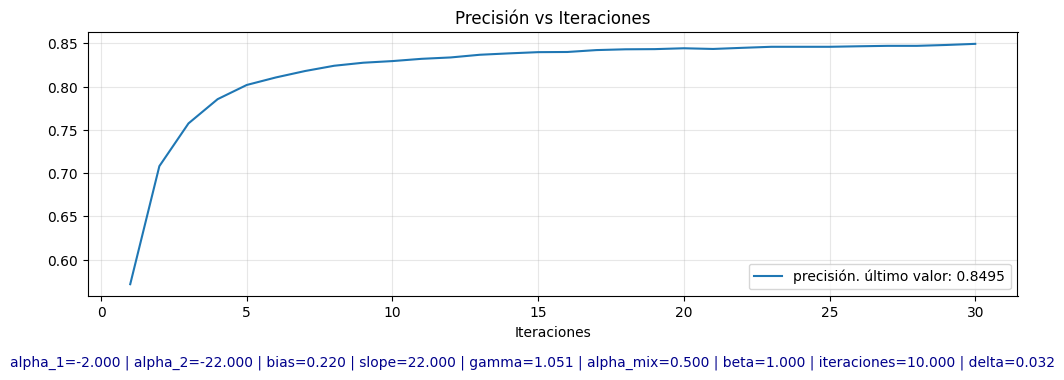

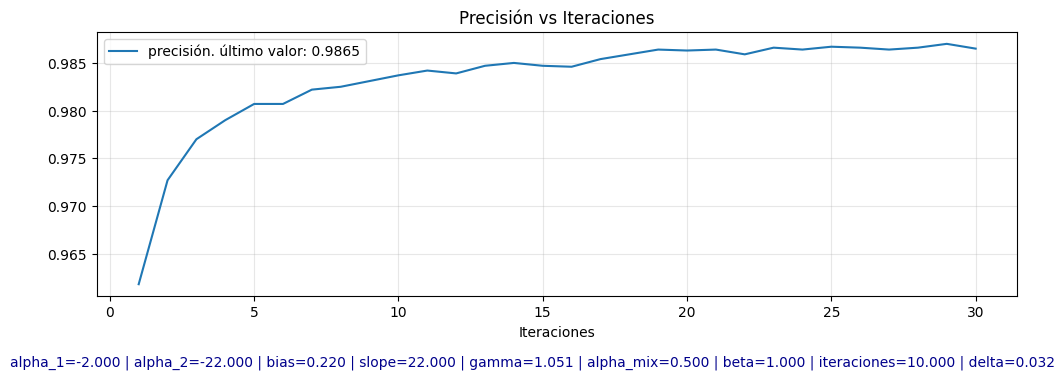

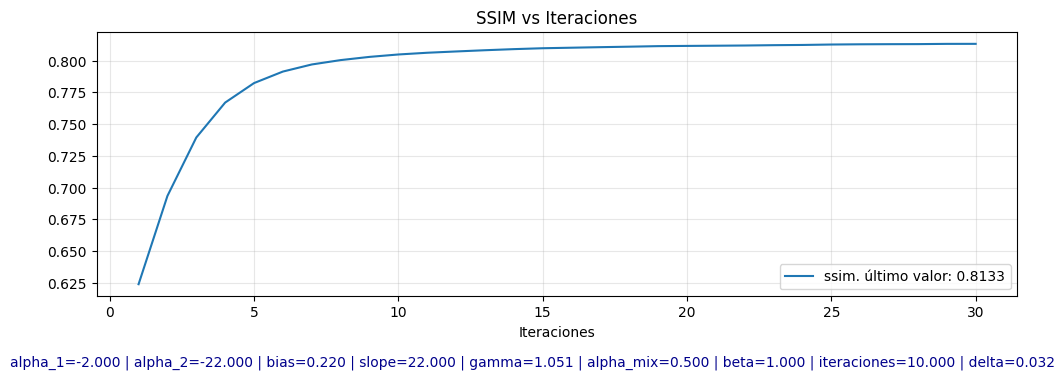

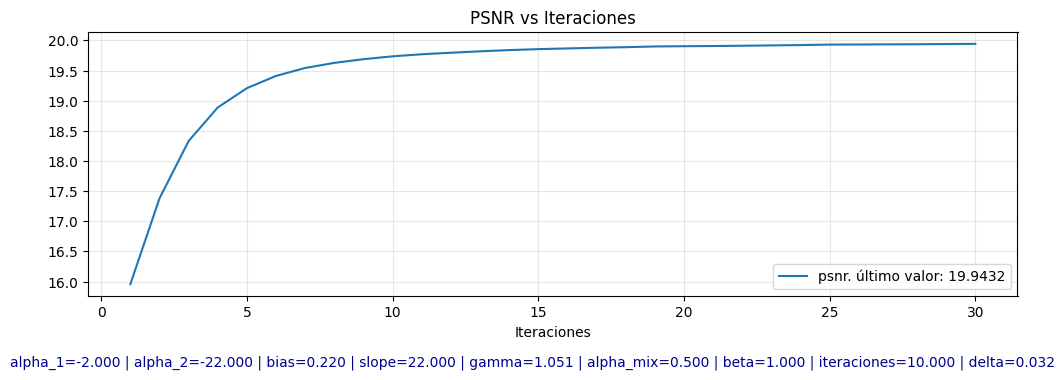


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.051
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.032

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.943  std:3.218
mask_bpsnr       : mean: 13.951  std:1.940
ssim             : mean: 0.813  std:0.104
acc_at_least_one : 0.987
acc_both         : 0.849

Run 2/10


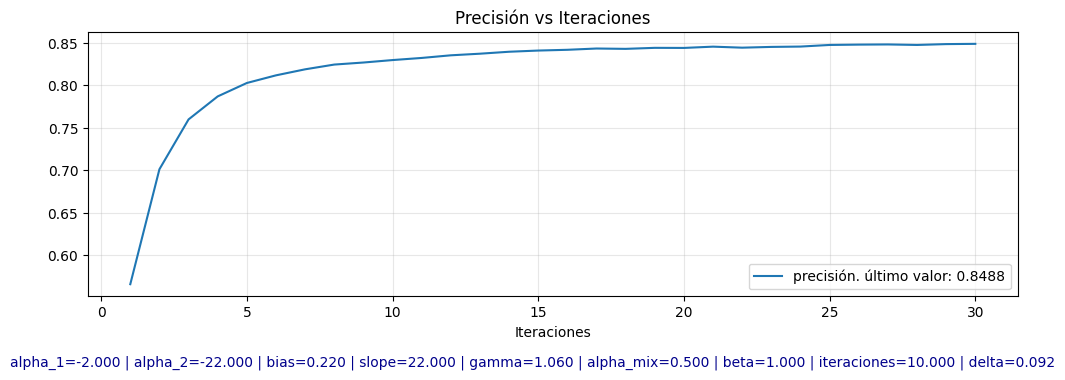

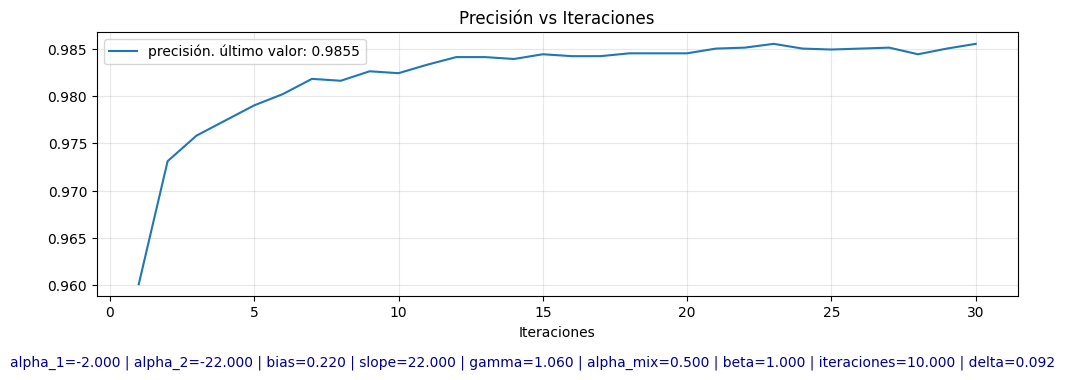

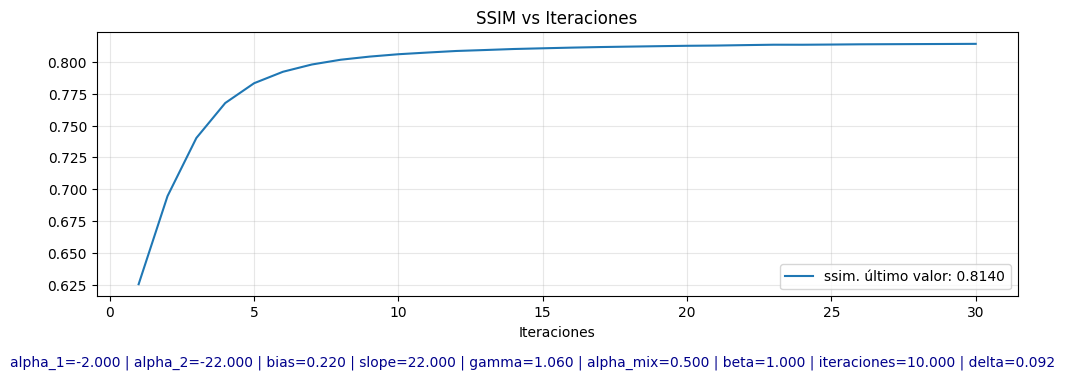

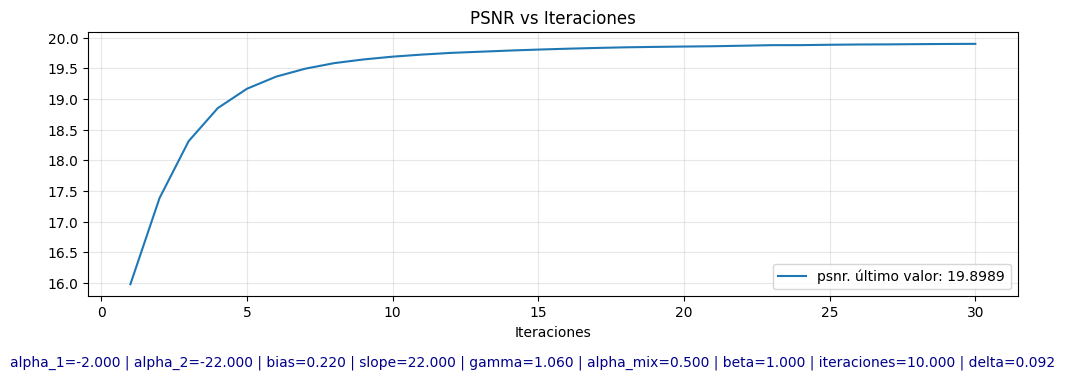


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.060
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.092

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.899  std:3.199
mask_bpsnr       : mean: 13.956  std:1.936
ssim             : mean: 0.814  std:0.104
acc_at_least_one : 0.986
acc_both         : 0.849



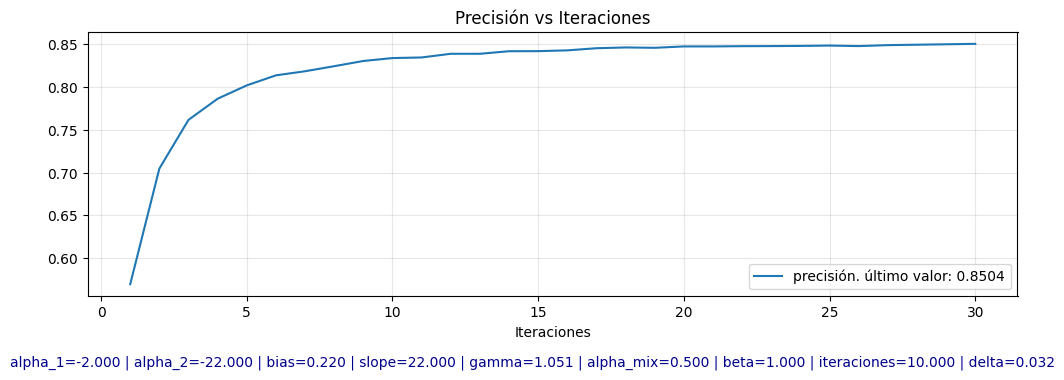

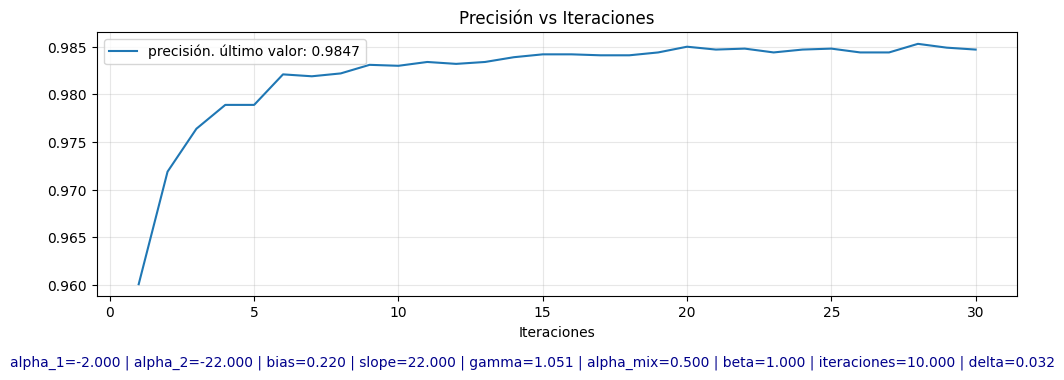

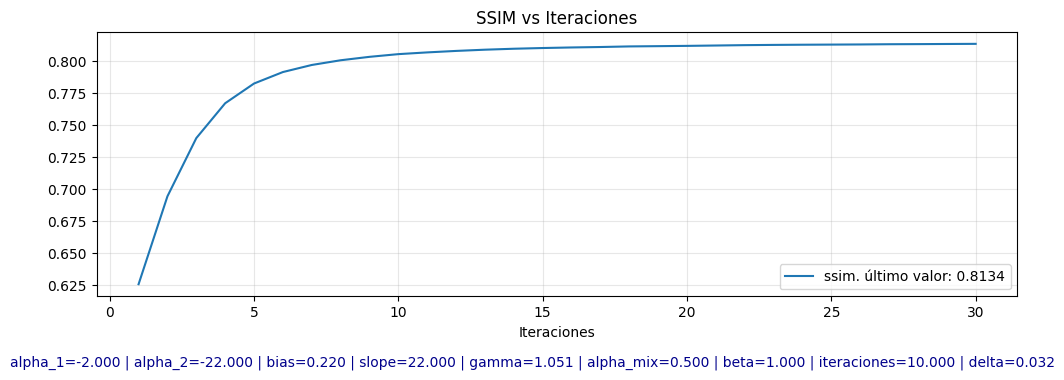

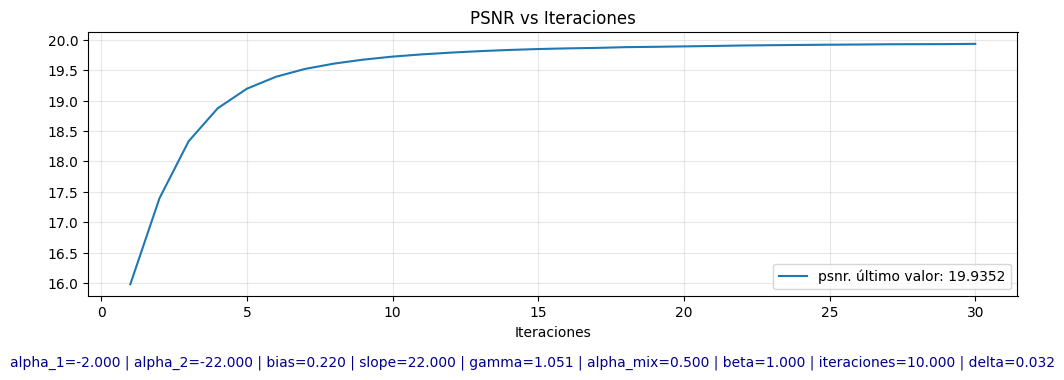


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.051
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.032

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.935  std:3.195
mask_bpsnr       : mean: 13.948  std:1.932
ssim             : mean: 0.813  std:0.103
acc_at_least_one : 0.985
acc_both         : 0.850

Run 3/10


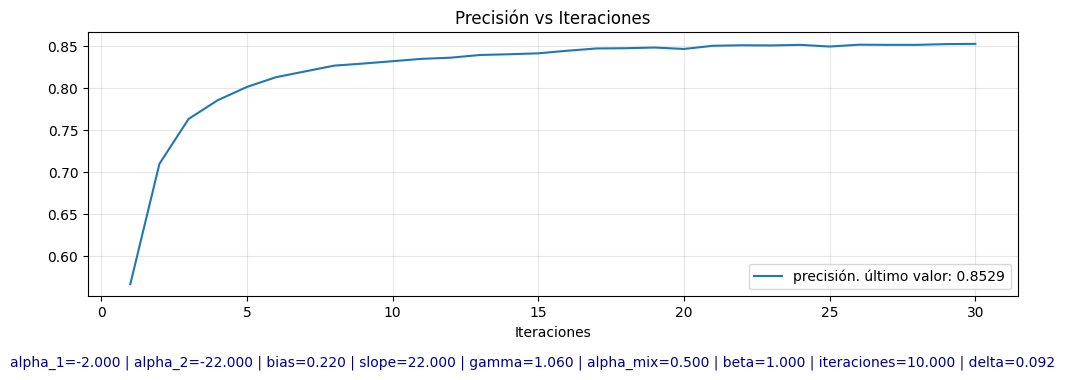

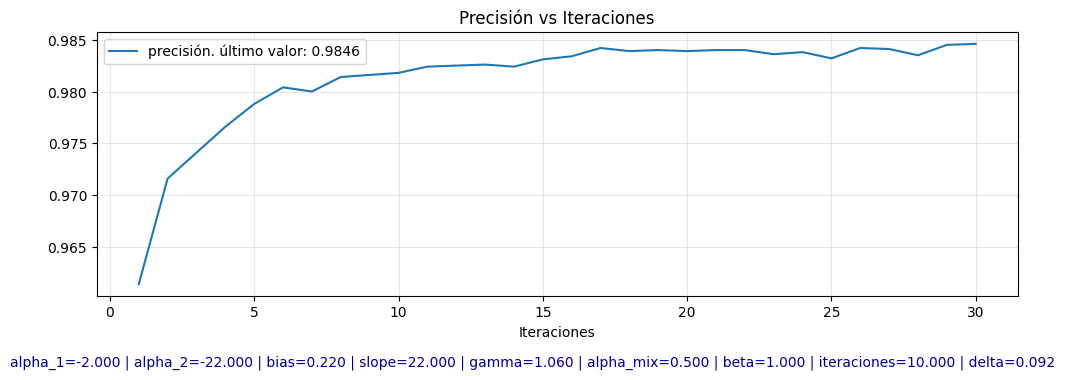

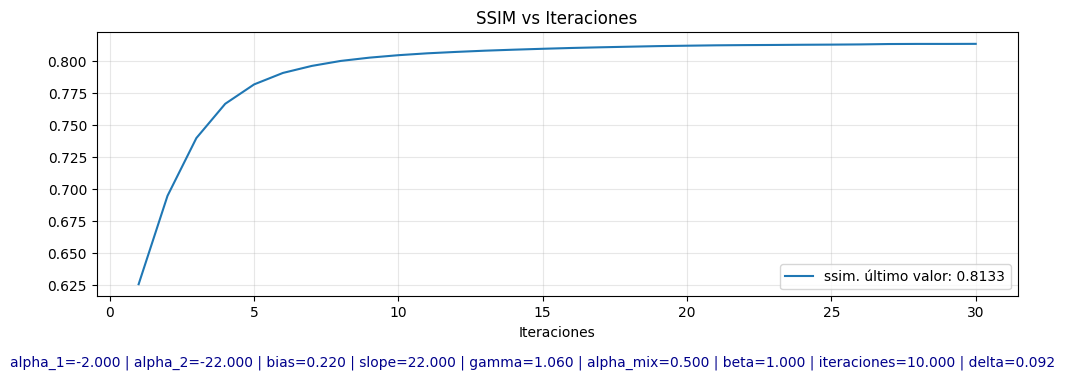

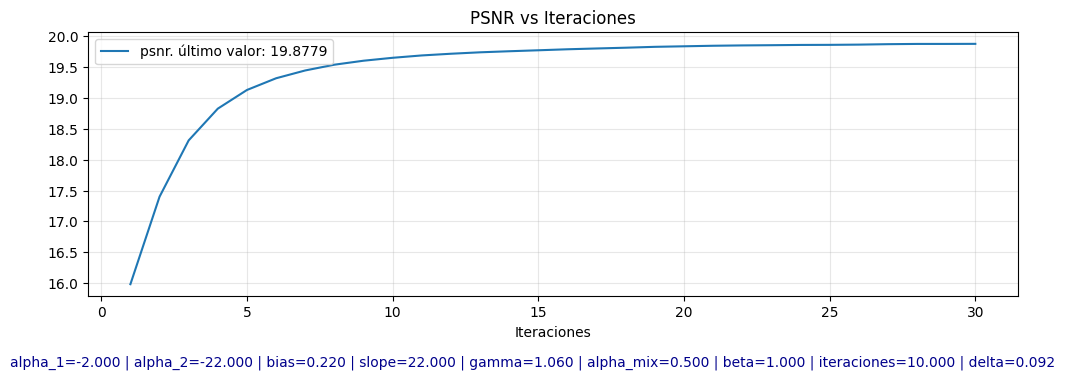


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.060
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.092

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.878  std:3.166
mask_bpsnr       : mean: 13.955  std:1.924
ssim             : mean: 0.813  std:0.104
acc_at_least_one : 0.985
acc_both         : 0.853



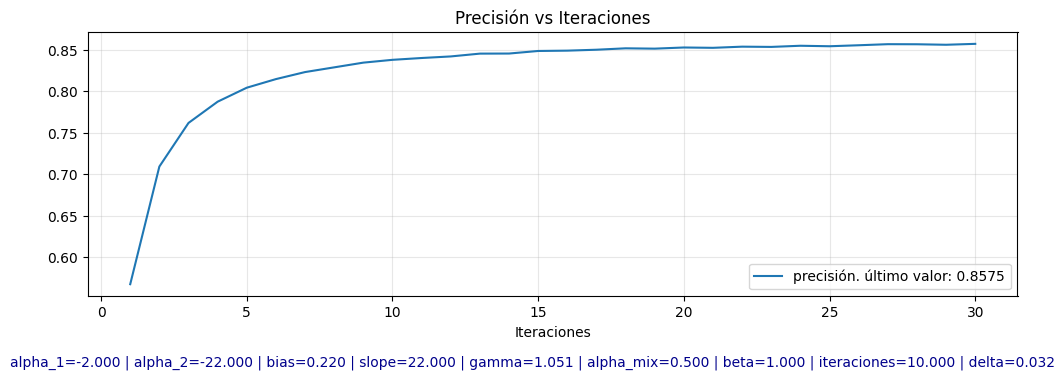

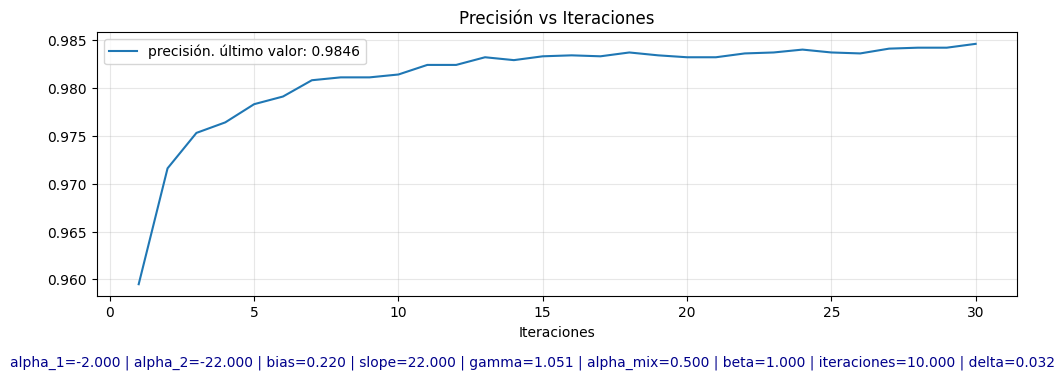

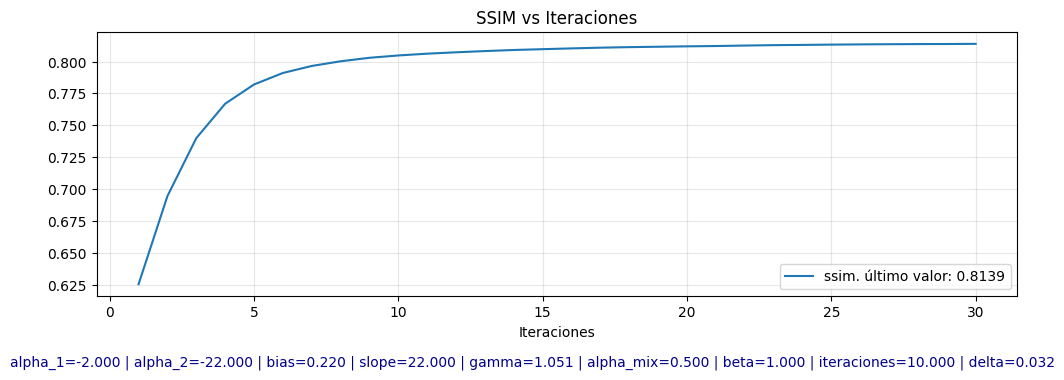

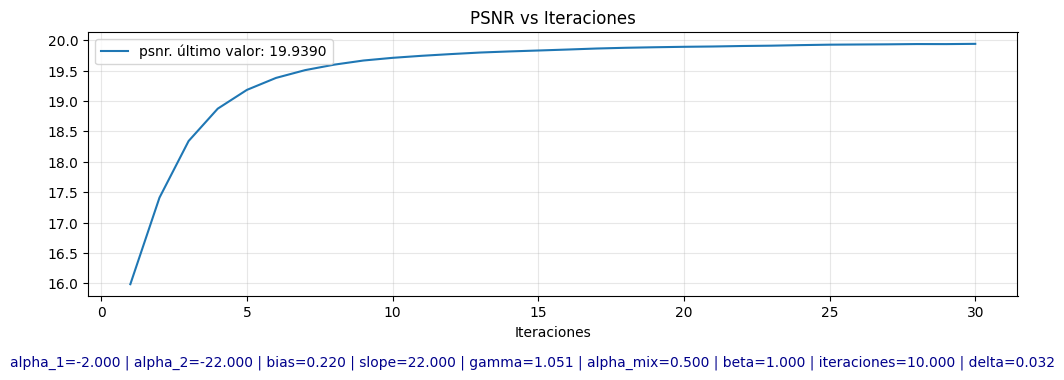


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.051
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.032

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.939  std:3.137
mask_bpsnr       : mean: 13.957  std:1.907
ssim             : mean: 0.814  std:0.102
acc_at_least_one : 0.985
acc_both         : 0.857

Run 4/10


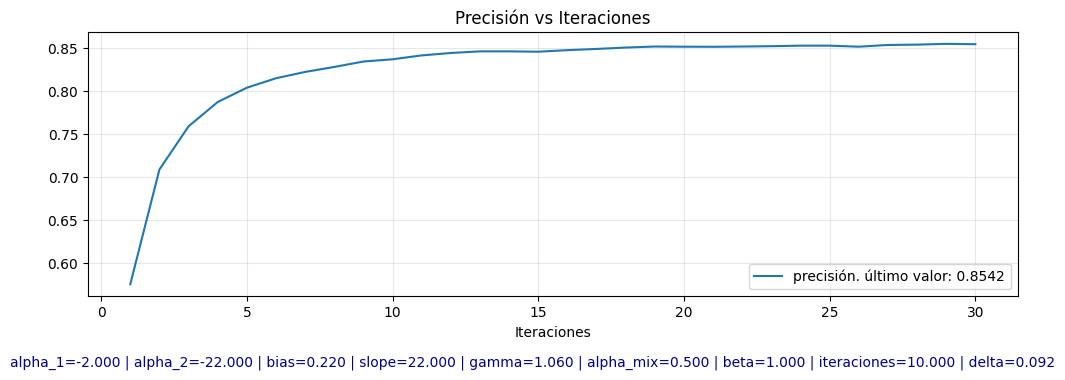

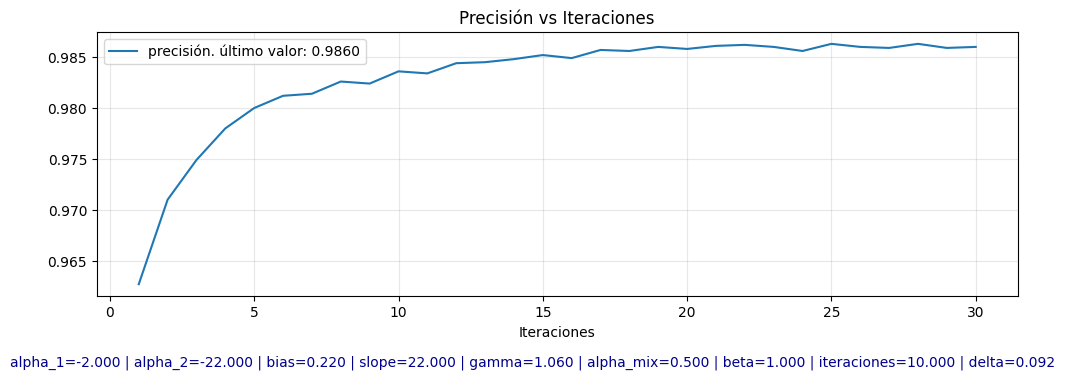

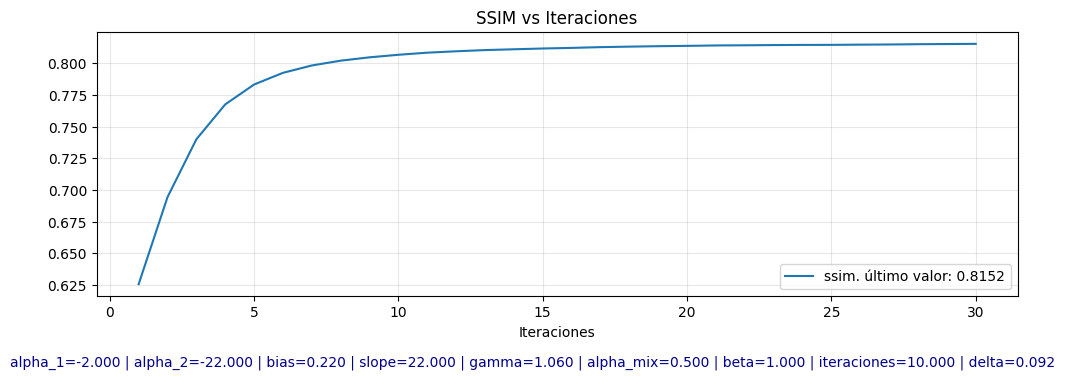

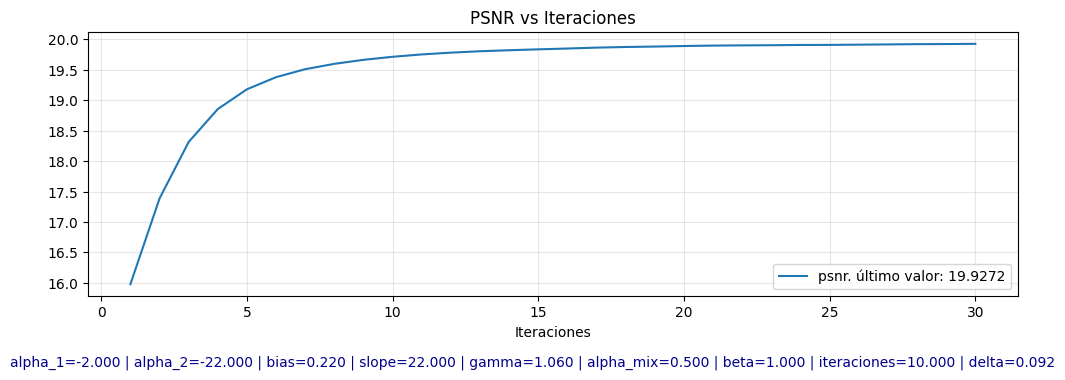


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.060
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.092

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.927  std:3.166
mask_bpsnr       : mean: 13.977  std:1.918
ssim             : mean: 0.815  std:0.103
acc_at_least_one : 0.986
acc_both         : 0.854



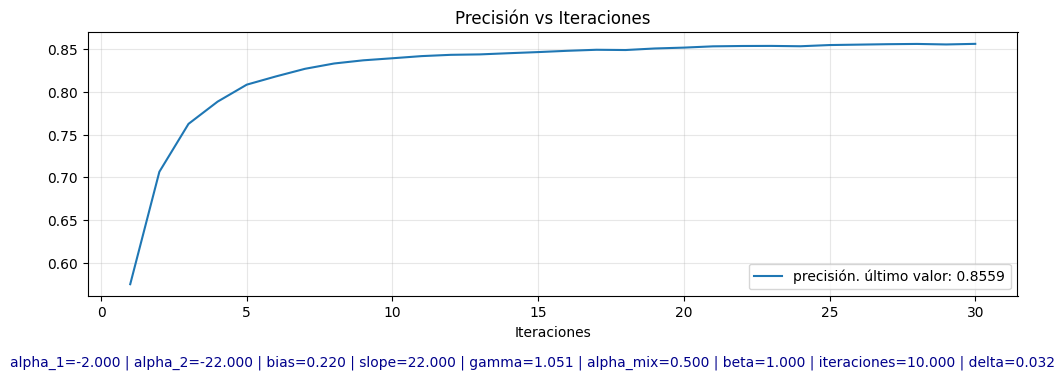

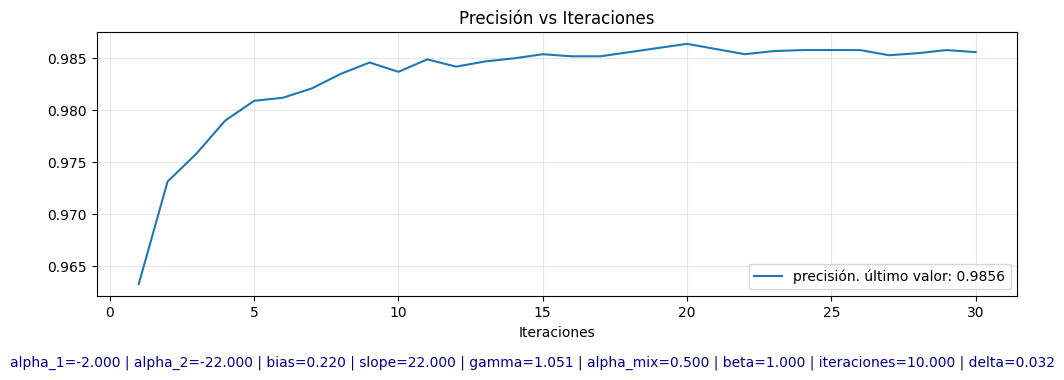

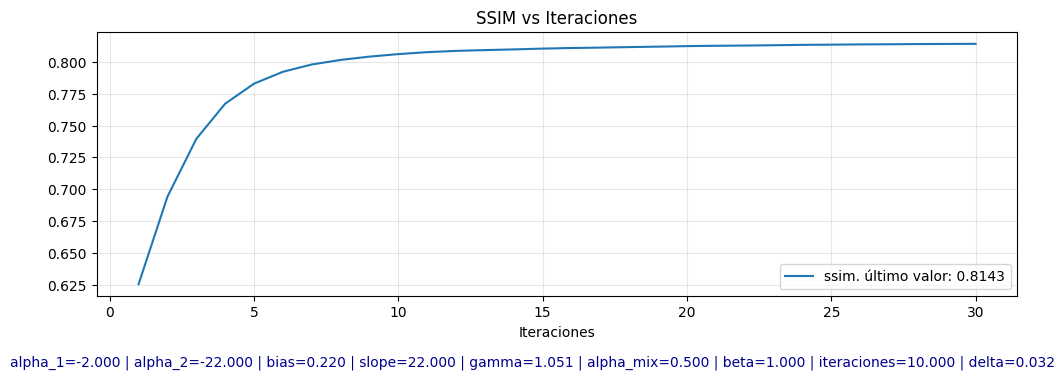

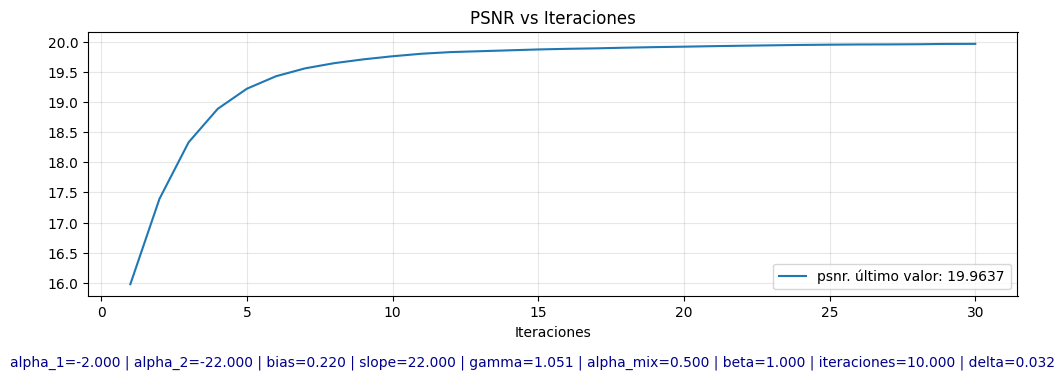


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.051
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.032

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.964  std:3.179
mask_bpsnr       : mean: 13.960  std:1.916
ssim             : mean: 0.814  std:0.103
acc_at_least_one : 0.986
acc_both         : 0.856

Run 5/10


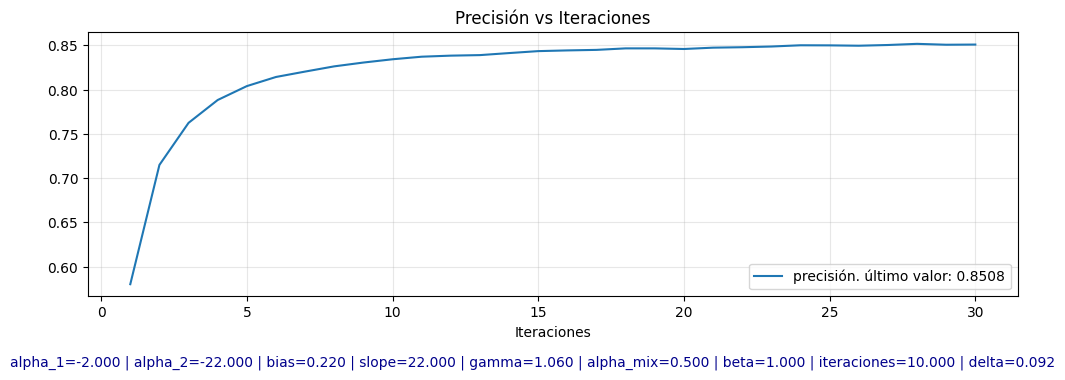

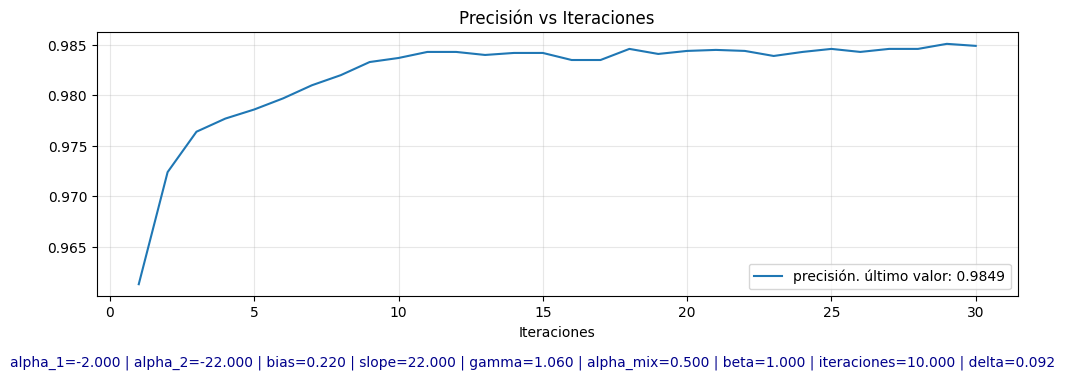

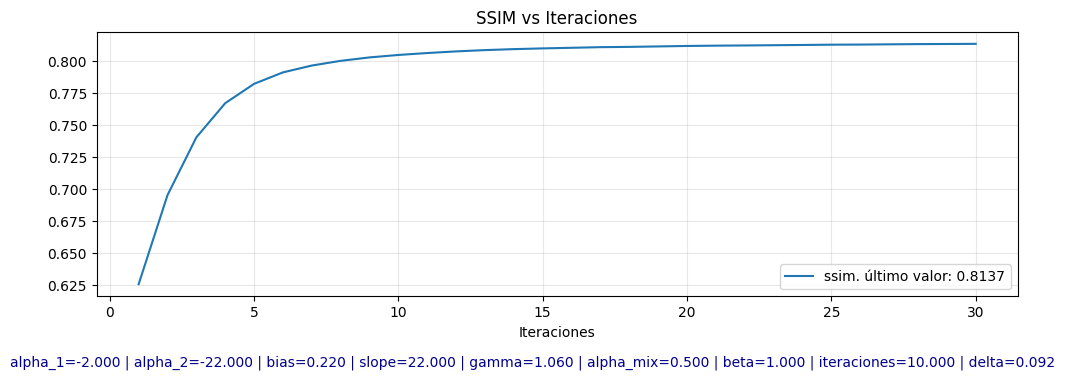

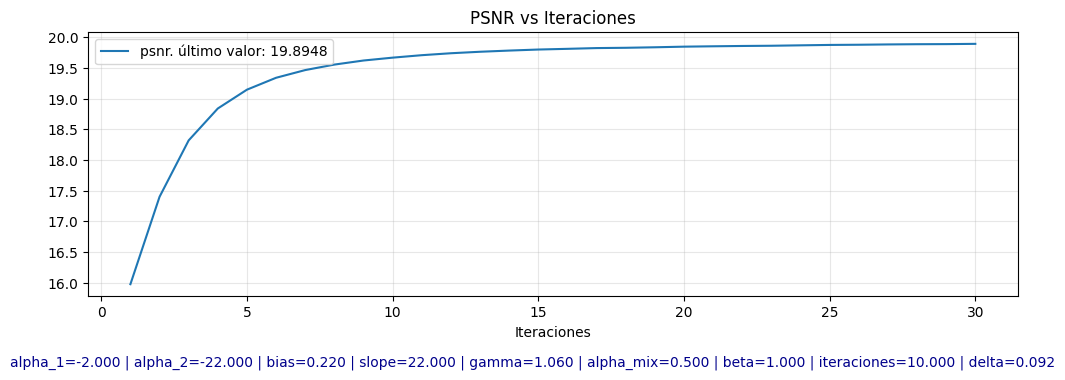


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.060
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.092

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.895  std:3.180
mask_bpsnr       : mean: 13.961  std:1.942
ssim             : mean: 0.814  std:0.105
acc_at_least_one : 0.985
acc_both         : 0.851



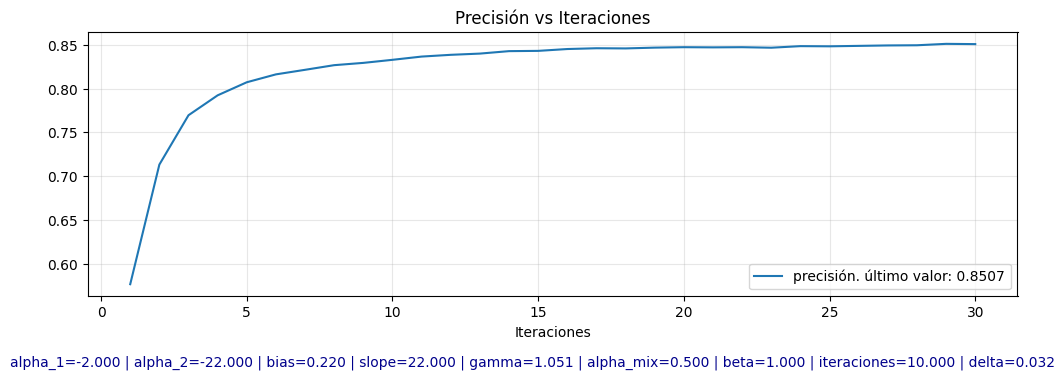

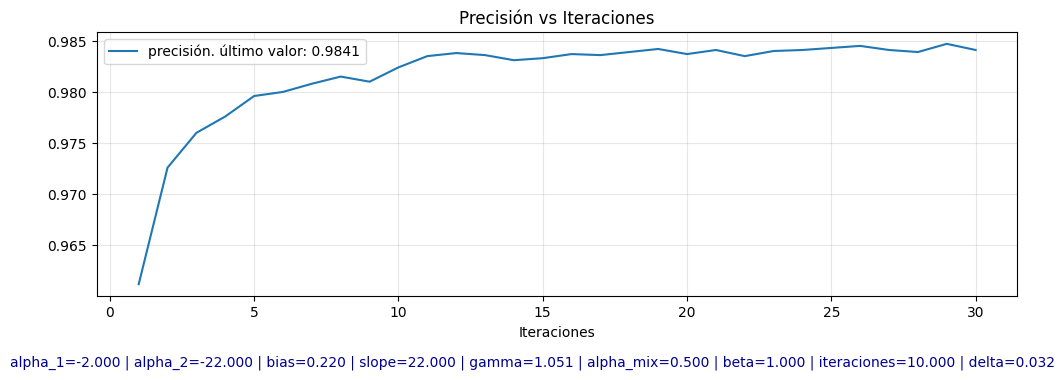

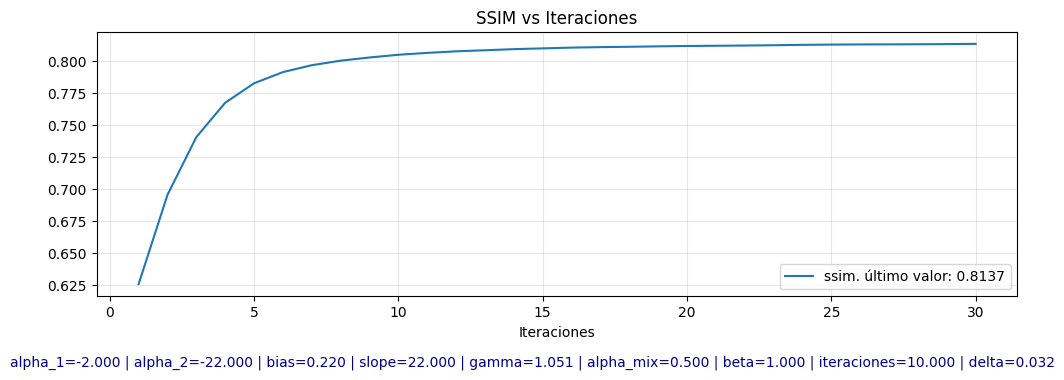

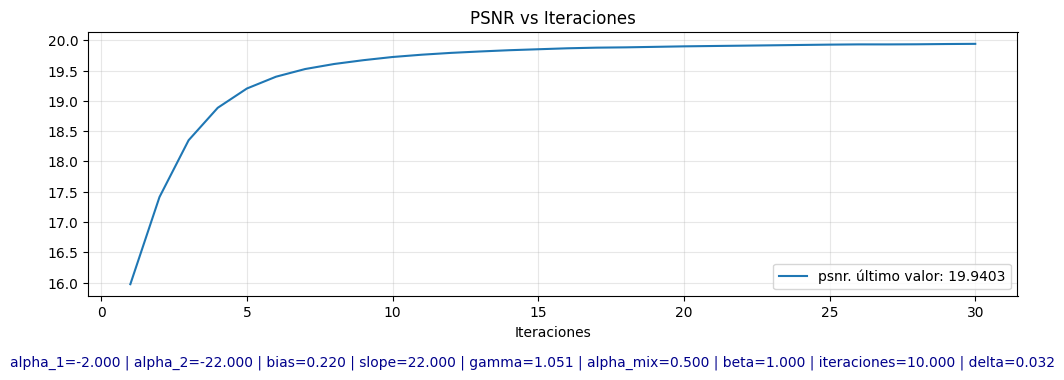


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.051
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.032

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.940  std:3.163
mask_bpsnr       : mean: 13.953  std:1.935
ssim             : mean: 0.814  std:0.103
acc_at_least_one : 0.984
acc_both         : 0.851

Run 6/10


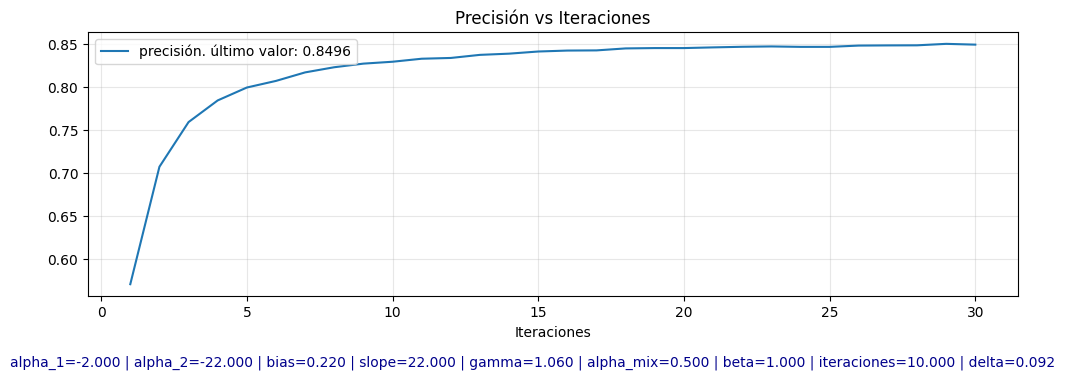

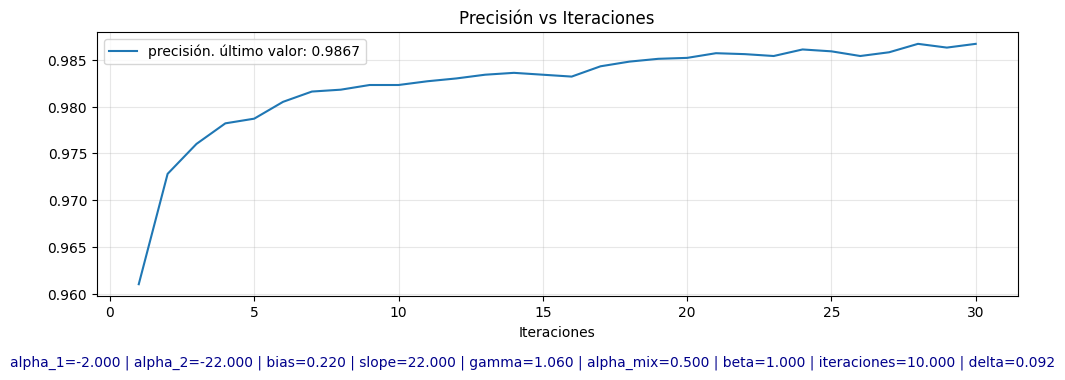

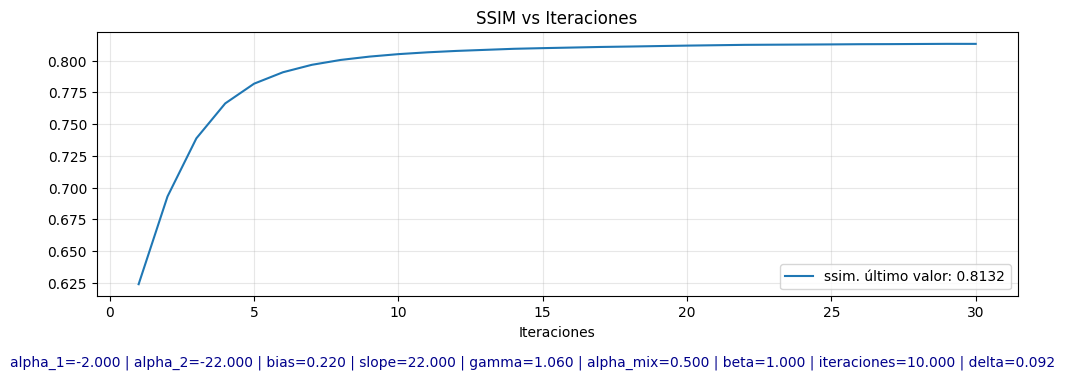

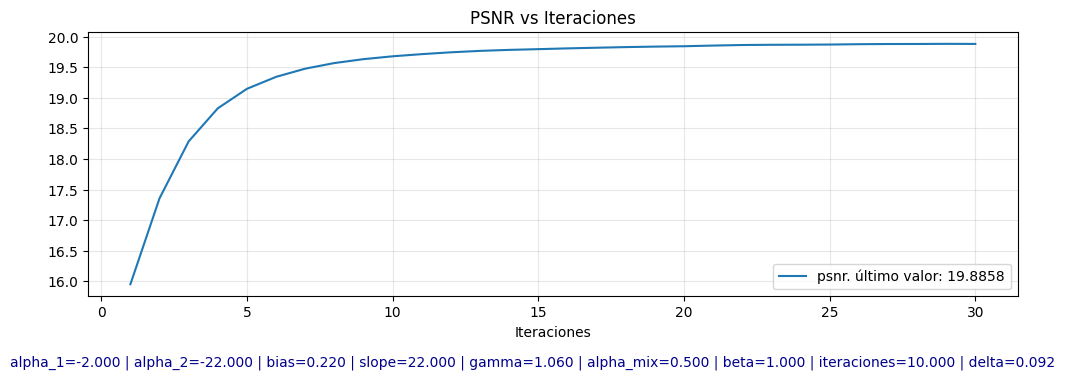


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.060
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.092

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.886  std:3.213
mask_bpsnr       : mean: 13.947  std:1.945
ssim             : mean: 0.813  std:0.105
acc_at_least_one : 0.987
acc_both         : 0.850



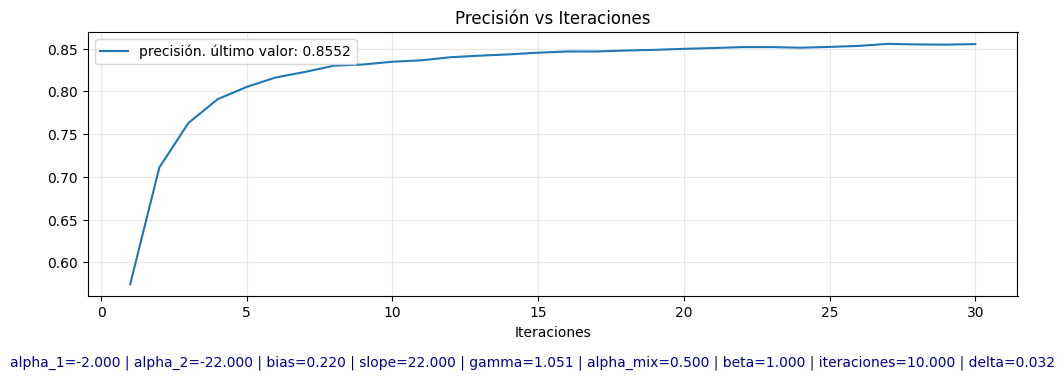

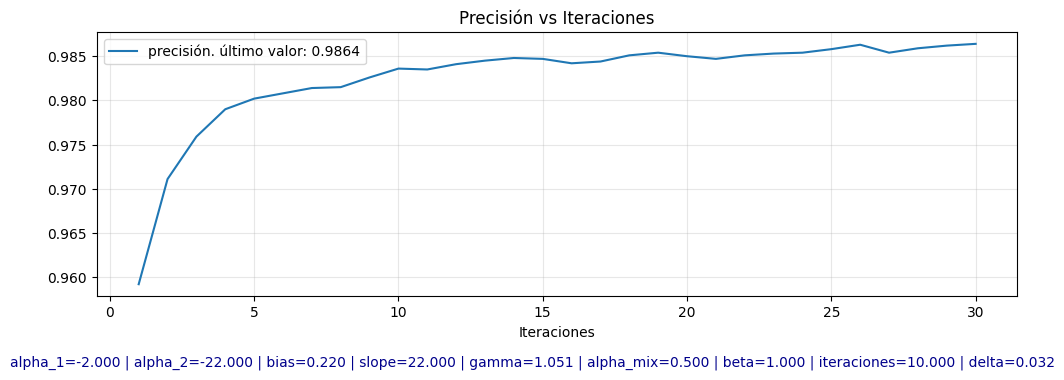

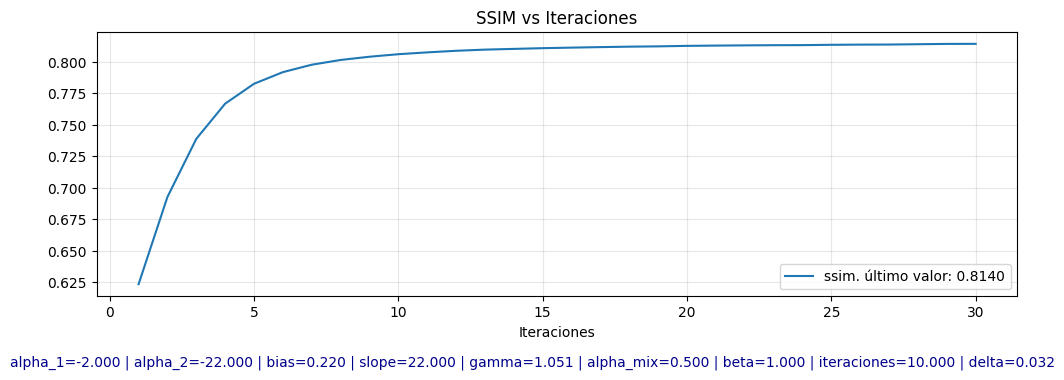

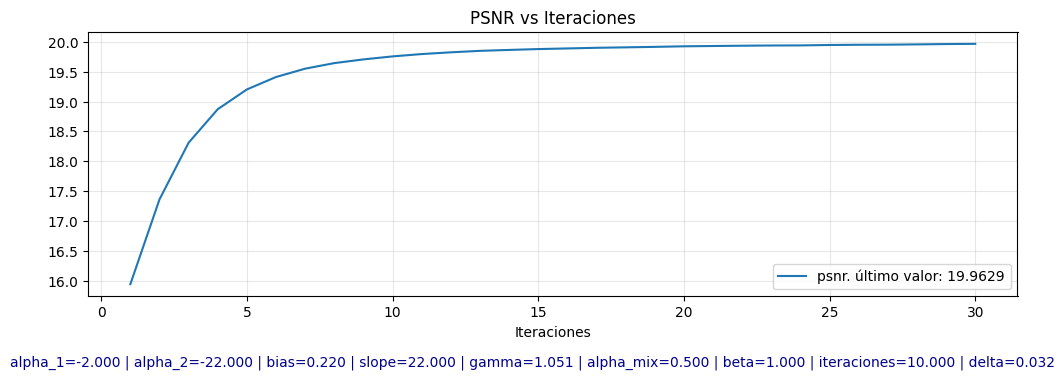


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.051
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.032

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.963  std:3.182
mask_bpsnr       : mean: 13.953  std:1.929
ssim             : mean: 0.814  std:0.103
acc_at_least_one : 0.986
acc_both         : 0.855

Run 7/10


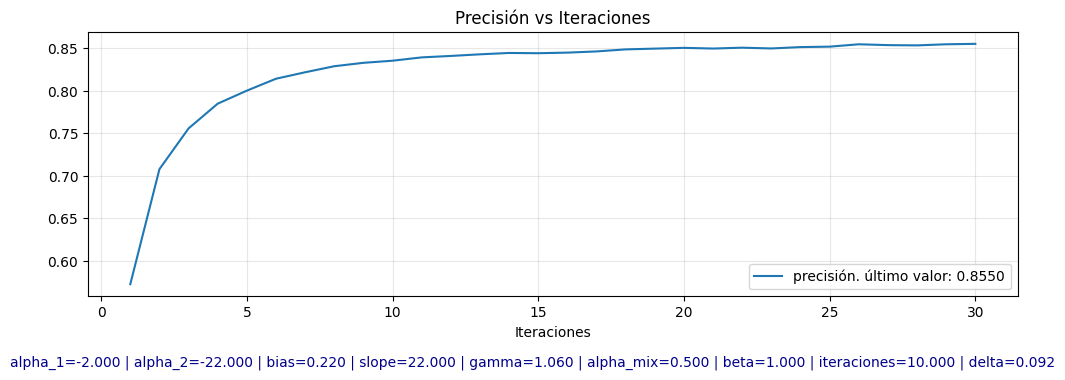

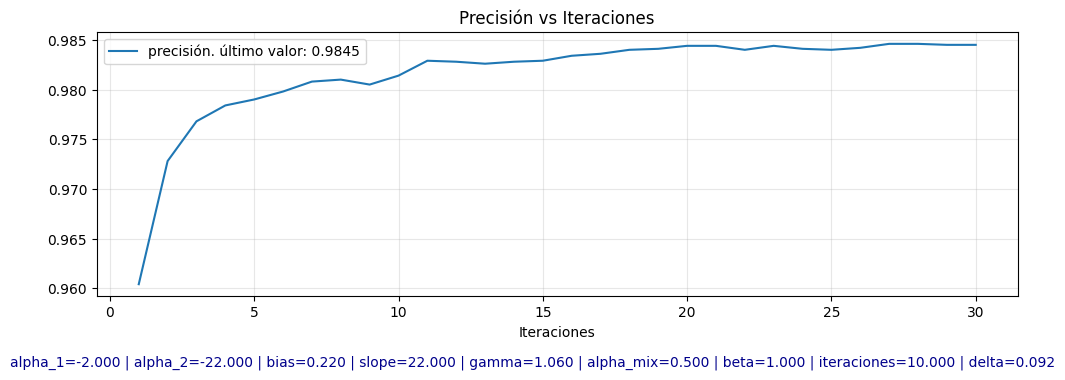

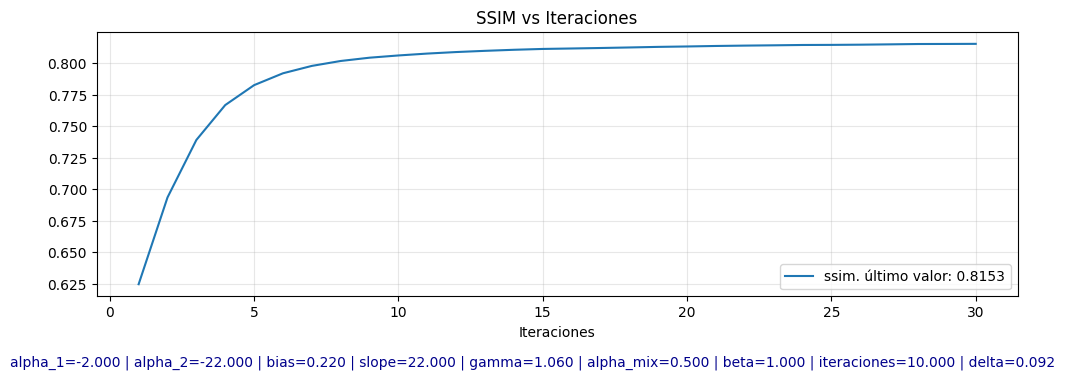

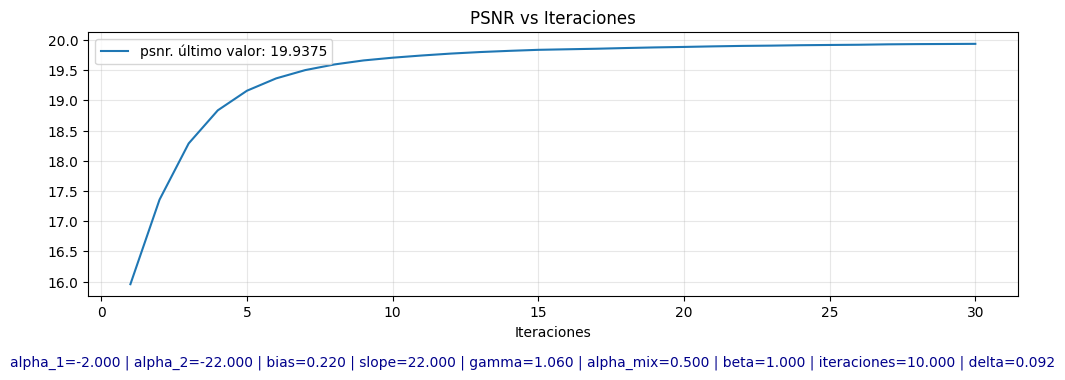


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.060
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.092

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.937  std:3.194
mask_bpsnr       : mean: 13.978  std:1.933
ssim             : mean: 0.815  std:0.103
acc_at_least_one : 0.985
acc_both         : 0.855



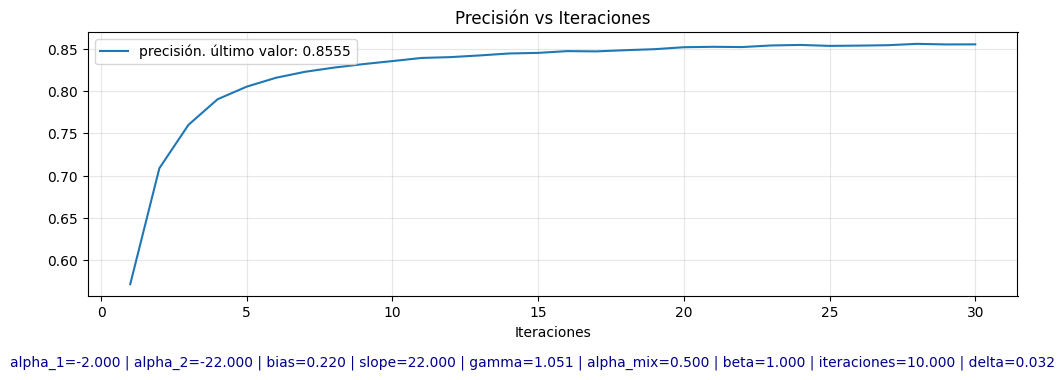

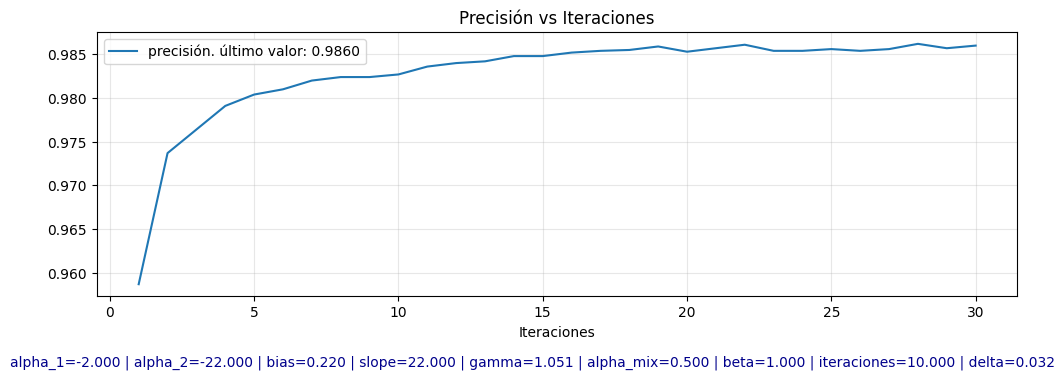

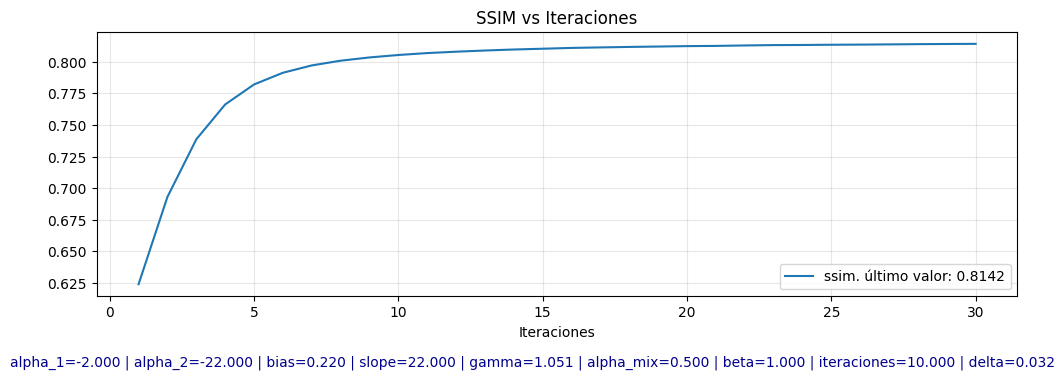

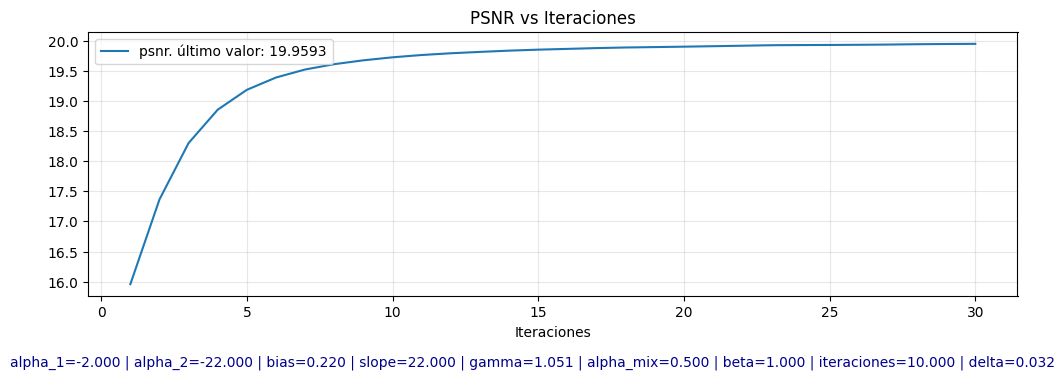


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.051
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.032

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.959  std:3.198
mask_bpsnr       : mean: 13.959  std:1.933
ssim             : mean: 0.814  std:0.103
acc_at_least_one : 0.986
acc_both         : 0.855

Run 8/10


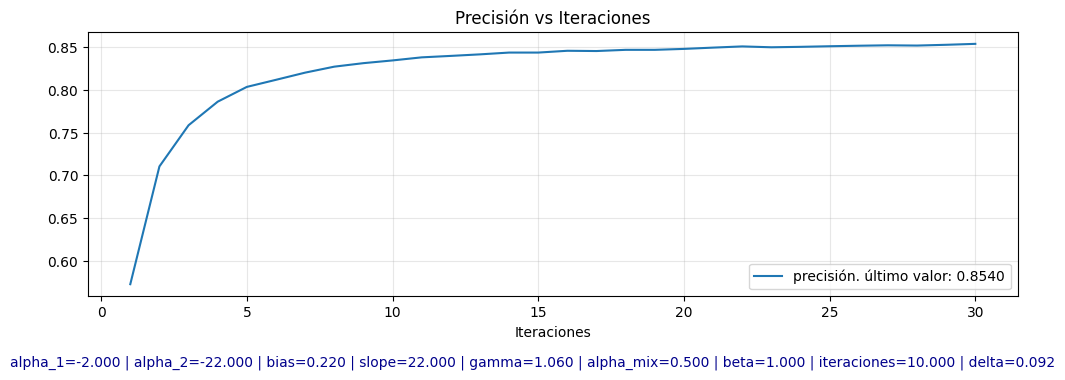

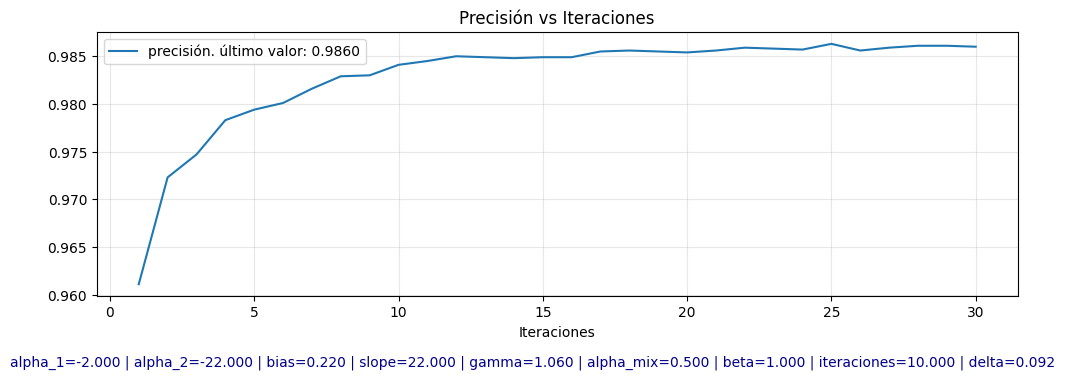

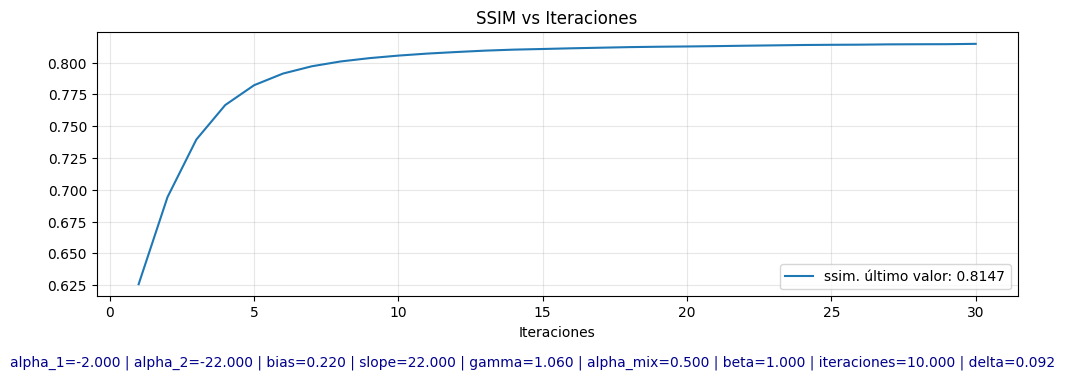

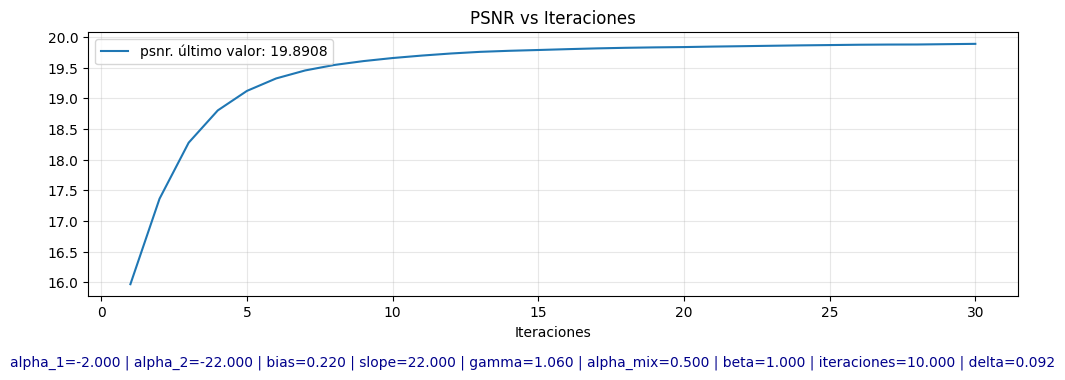


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.060
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.092

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.891  std:3.179
mask_bpsnr       : mean: 13.961  std:1.923
ssim             : mean: 0.815  std:0.102
acc_at_least_one : 0.986
acc_both         : 0.854



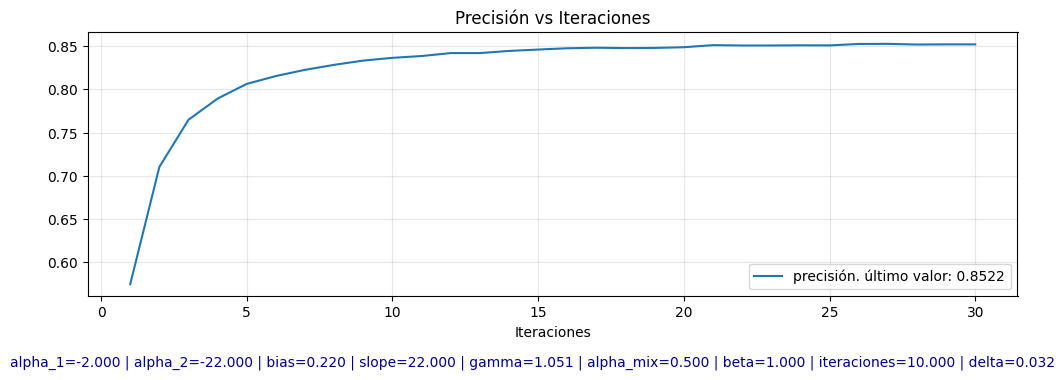

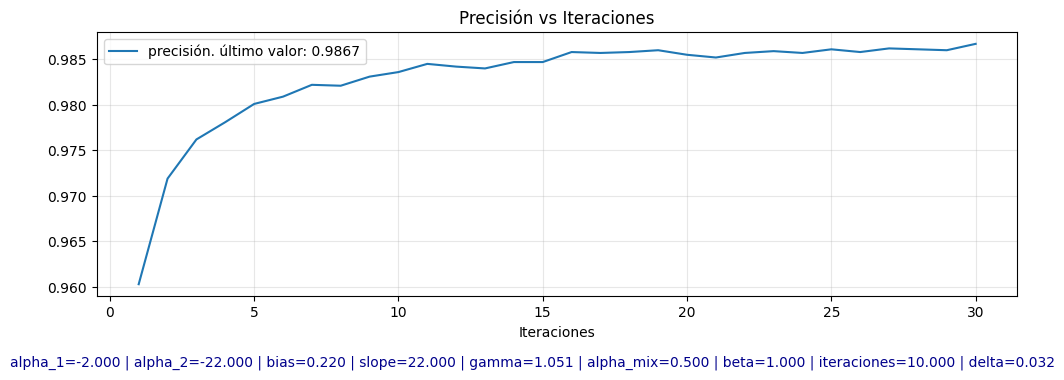

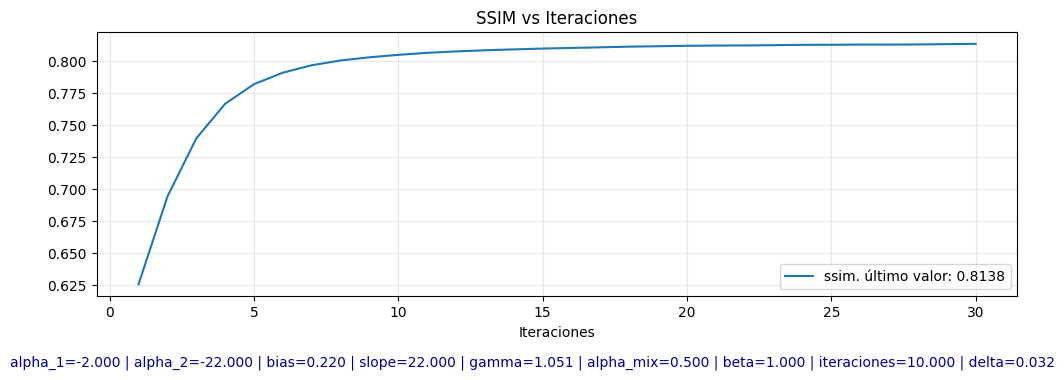

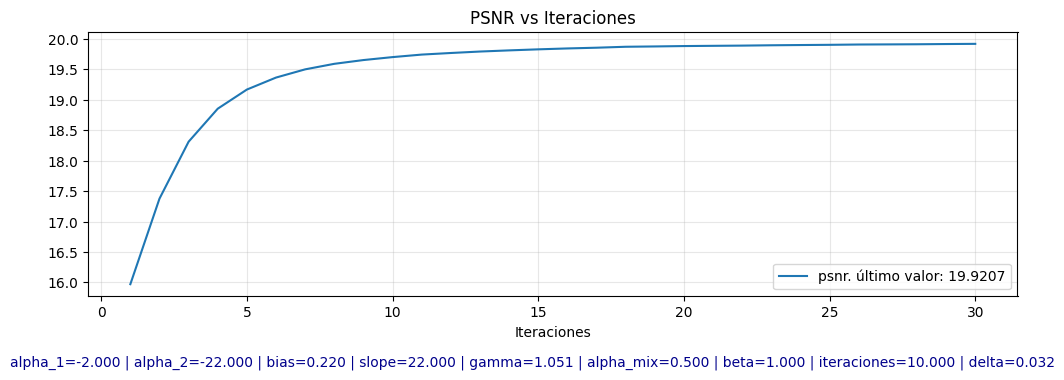


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.051
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.032

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.921  std:3.189
mask_bpsnr       : mean: 13.944  std:1.923
ssim             : mean: 0.814  std:0.103
acc_at_least_one : 0.987
acc_both         : 0.852

Run 9/10


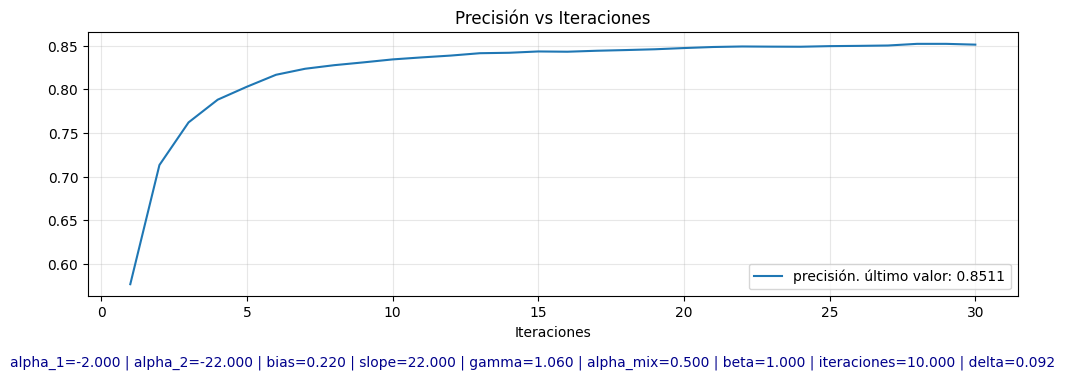

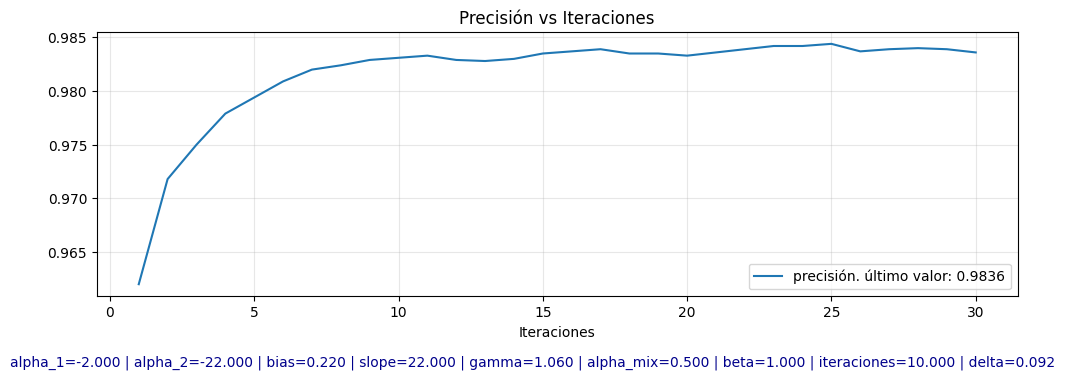

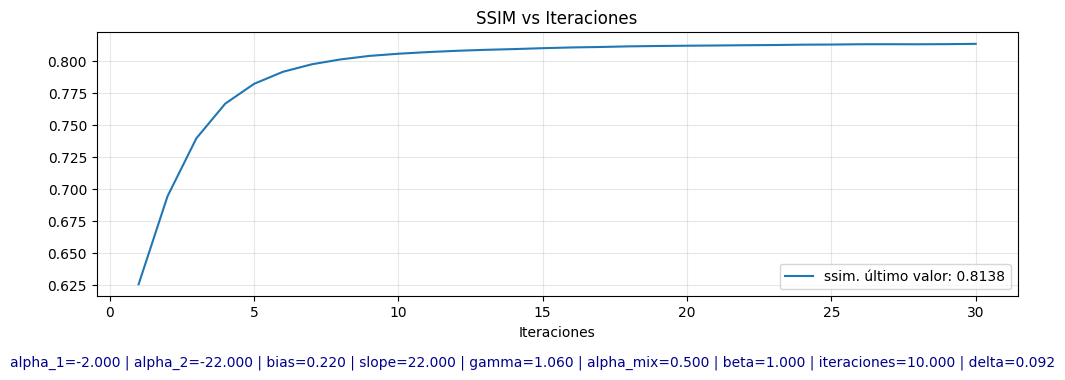

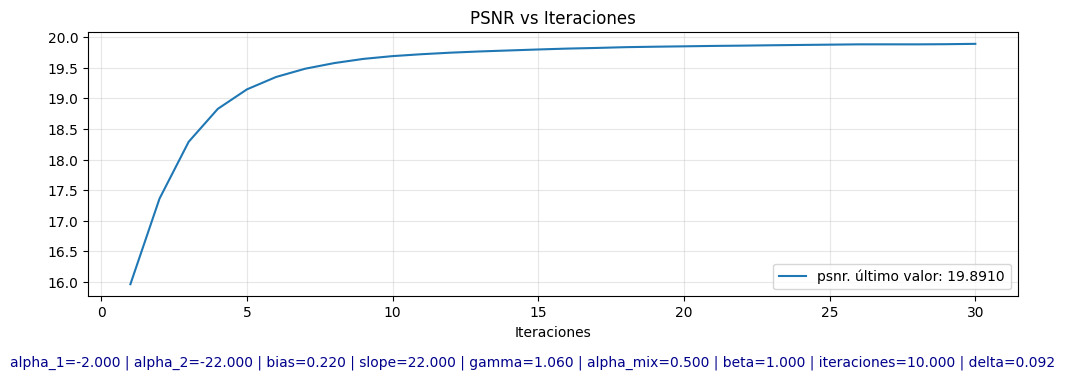


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.060
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.092

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.891  std:3.207
mask_bpsnr       : mean: 13.961  std:1.941
ssim             : mean: 0.814  std:0.104
acc_at_least_one : 0.984
acc_both         : 0.851



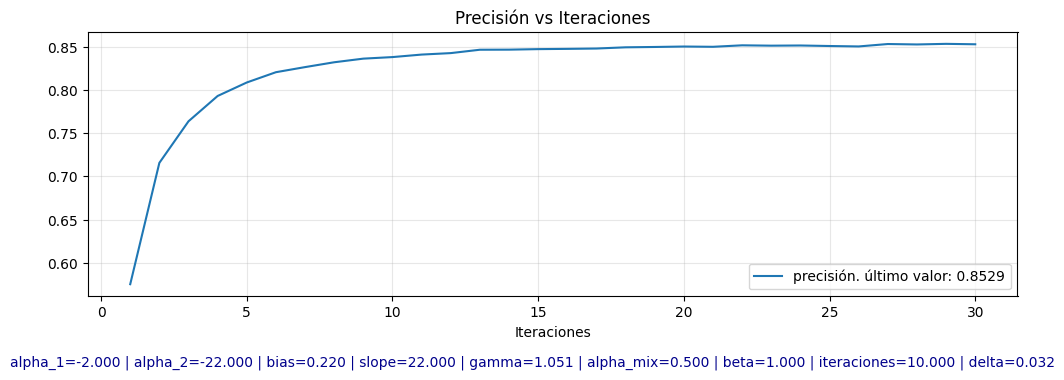

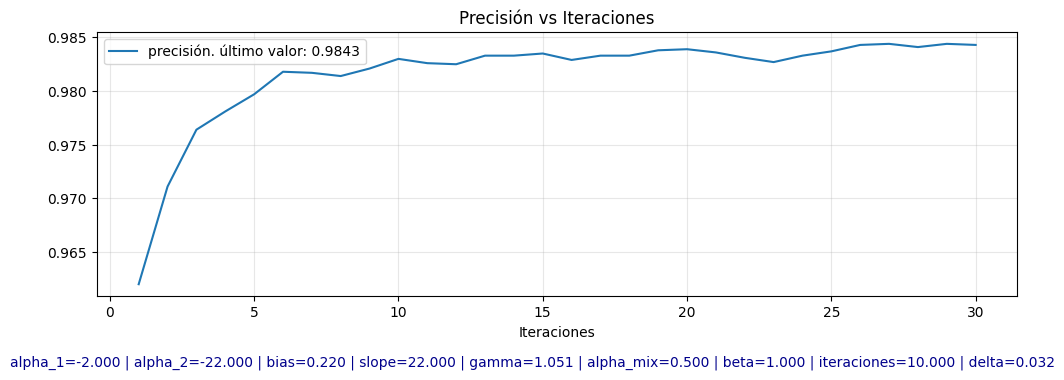

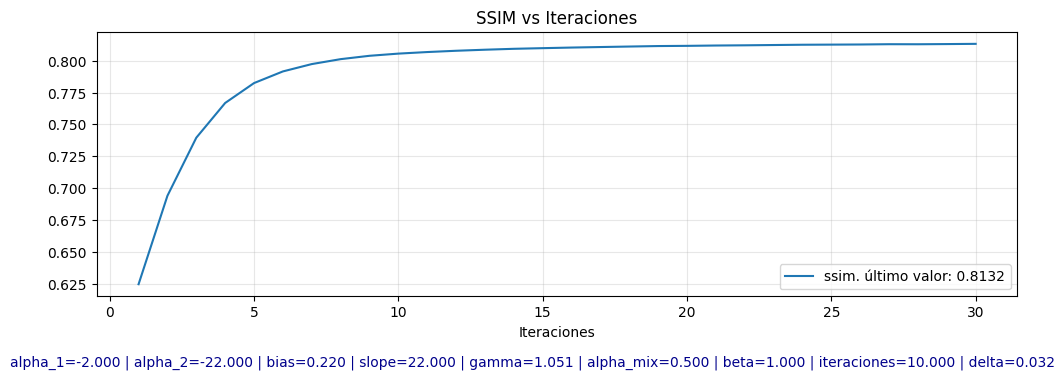

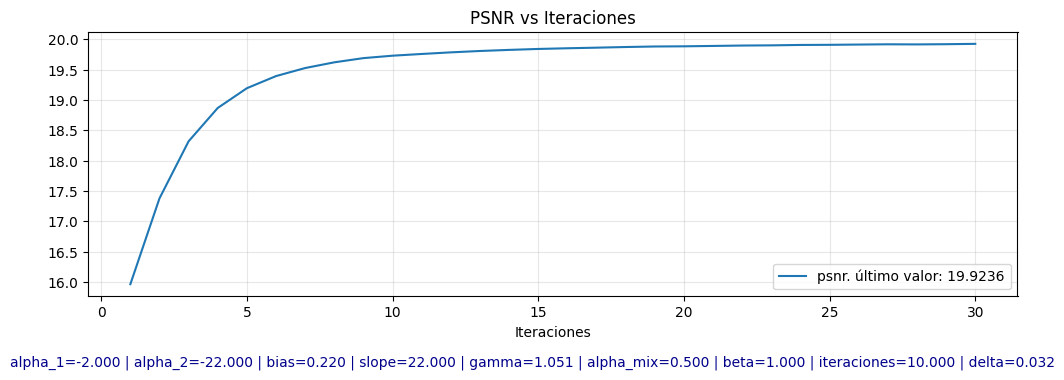


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.051
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.032

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.924  std:3.200
mask_bpsnr       : mean: 13.946  std:1.926
ssim             : mean: 0.813  std:0.103
acc_at_least_one : 0.984
acc_both         : 0.853

Run 10/10


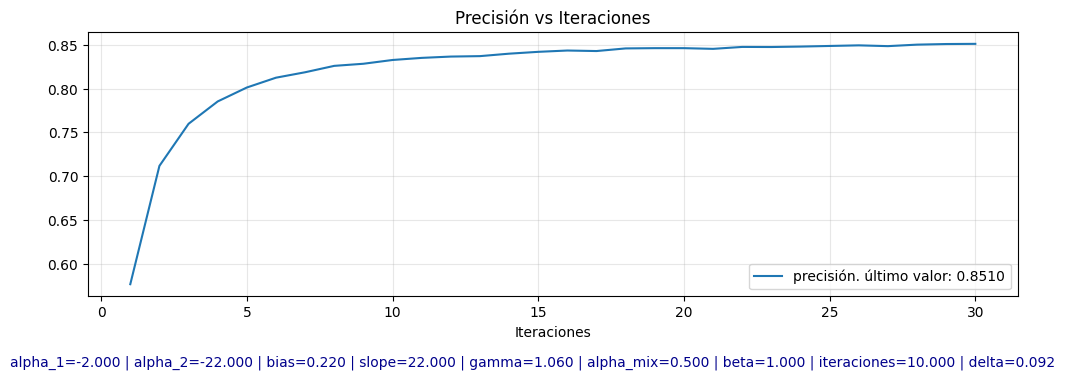

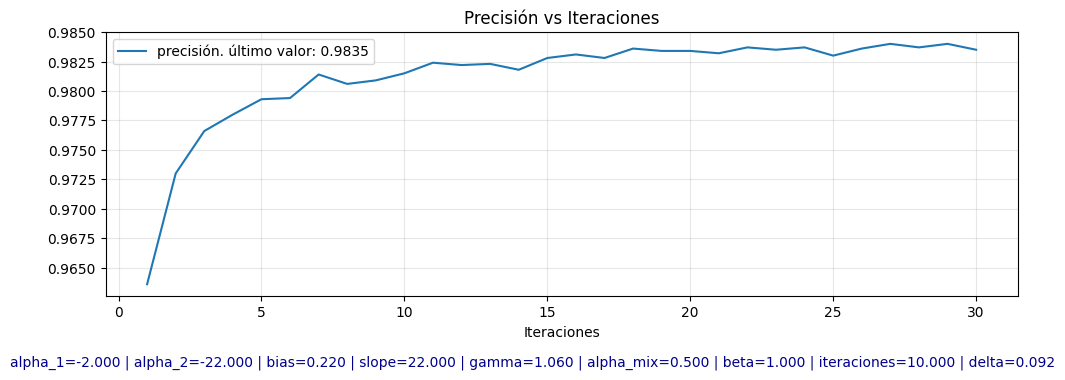

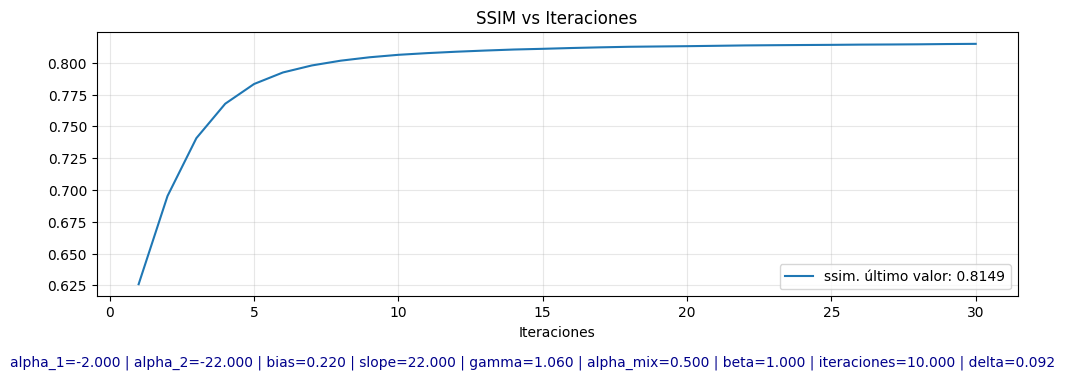

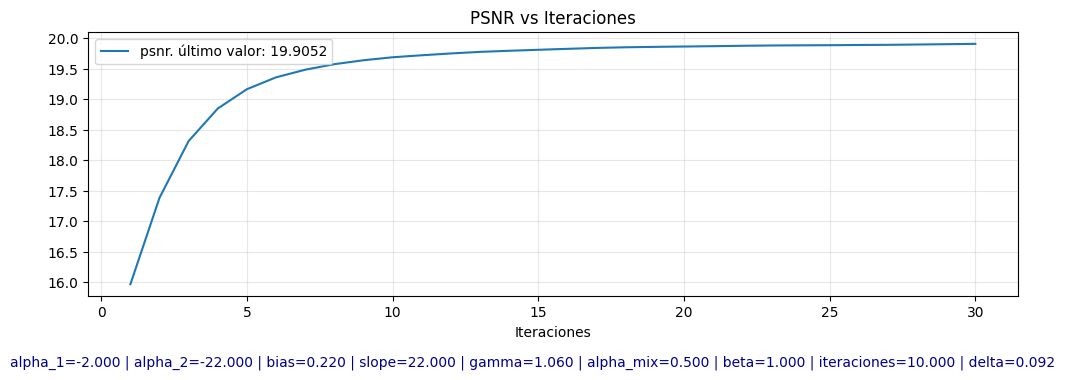


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.060
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.092

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.905  std:3.185
mask_bpsnr       : mean: 13.972  std:1.935
ssim             : mean: 0.815  std:0.103
acc_at_least_one : 0.984
acc_both         : 0.851



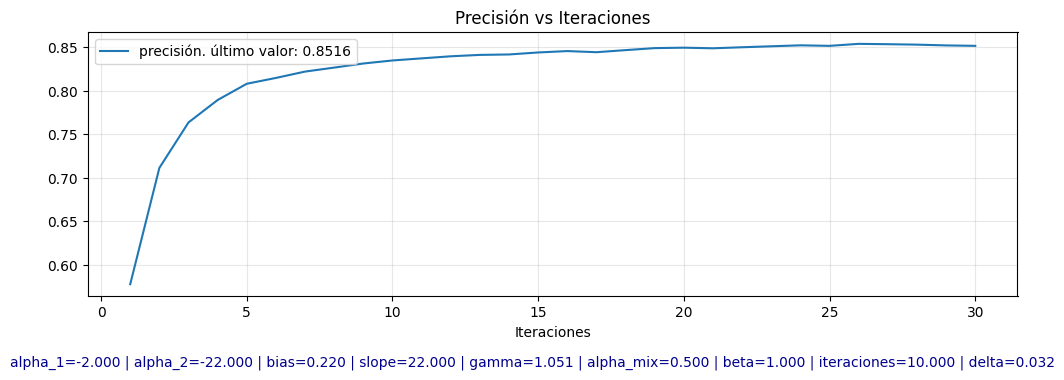

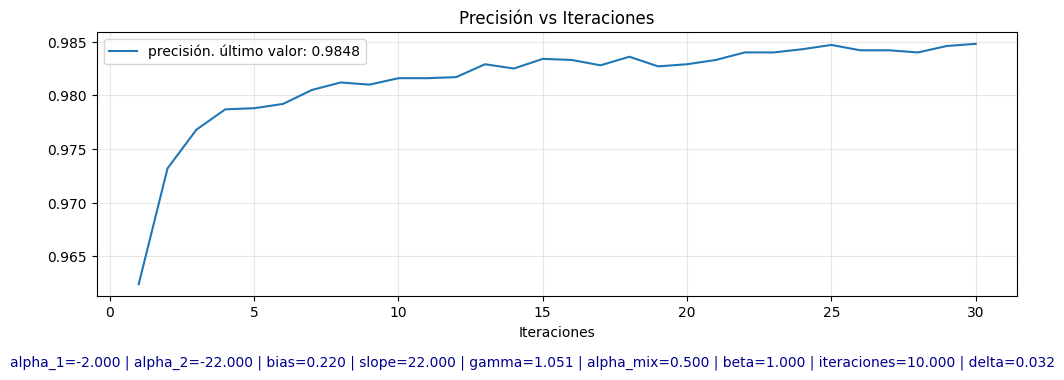

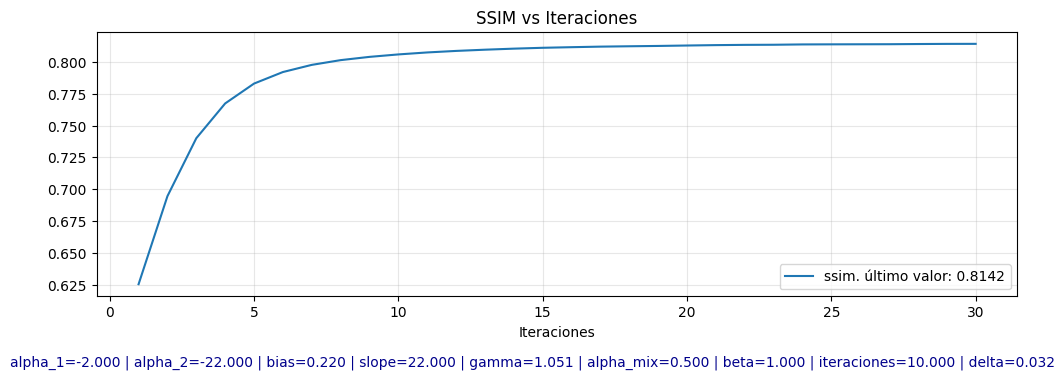

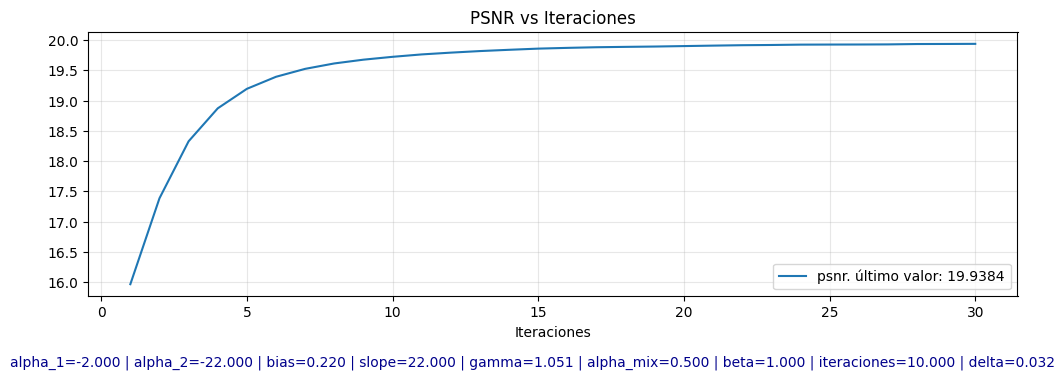


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.051
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.032

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.938  std:3.165
mask_bpsnr       : mean: 13.957  std:1.922
ssim             : mean: 0.814  std:0.102
acc_at_least_one : 0.985
acc_both         : 0.852



In [17]:

import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))
from project.loader import Loader
from project.metrics.metrics import Metrics 
from project.CROP.models.crop2 import Crop2
from project.CROP.models.crop3_estimation_correction import Crop3EstimationCorrection
from project.CROP.models.crop3_mask_correction import Crop3MaskCorrection
from project.CROP.models.crop3_all_corrections import Crop3AllCorrections
from project.CROP.models.crop3_one_hot import Crop3OH
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random



DATASET = "mnist" # mnist o fashion
LAT = 64
INTER = 256


cvae = Loader.cvae(inter=INTER,lat=LAT,dataset=DATASET)
data = Loader.data(dataset=DATASET)

predictor = Loader.predictor(dataset=DATASET)

N_RUNS = 10

ITERATIONS = 30
N_PICTURES = -1


results_crop2 = {
    "acc": [],
    "ssim": [],
    "psnr": []
}

results_crop3 = {
    "acc": [],
    "ssim": [],
    "psnr": []
}


x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]
labels= data["labels"]

for run in range(N_RUNS):

    print(f"Run {run+1}/{N_RUNS}")

    # --------------------------
    # Randomización grupo 1
    # --------------------------
    idx0 = np.random.permutation(len(x_test))

    X0 = x_test[idx0][:N_PICTURES]
    Y0 = y_test[idx0][:N_PICTURES]

    # --------------------------
    # Randomización grupo 2
    # --------------------------
    idx1 = np.random.permutation(len(x_test_1))

    X1 = x_test_1[idx1][:N_PICTURES]
    Y1 = y_test_1[idx1][:N_PICTURES]

    # ==================================================
    # Crop2
    # ==================================================
    c2 = Crop2(
        cvae=cvae,
        predictor=predictor
    )

    metrics2 = c2.unmix(
        X0,
        X1,
        Y0,
        Y1,
        iterations=ITERATIONS,
        show_image=False,
        labels=labels,
        #params={'gamma': 0.7267875665823903}, #fashion acc
        #params={'gamma': 1.3737512979787159}, #fashion ssim crop2 -> crop3
        #params={'gamma': 0.9256608959277062},# mnist acc
        params={'gamma': 1.0602623807869416,'delta': 0.09236729663810188},# mnist ssim crop2-->crop3
        show_all_curves=True
    )

    results_crop2["acc"].append(metrics2["acc_both_plot"])
    results_crop2["ssim"].append(metrics2["ssim_plot"])
    results_crop2["psnr"].append(metrics2["psnr_plot"])

    # ==================================================
    # Crop3 Estimation Correction
    # ==================================================
    c3 = Crop3EstimationCorrection(
        cvae=cvae,
        predictor=predictor
    )

    metrics3 = c3.unmix(
        X0,
        X1,
        Y0,
        Y1,
        iterations=ITERATIONS,
        show_image=False,
        labels=labels,
        params={'gamma': 1.0507384749934656, 'delta': 0.03166310123273044},
        #params={'gamma': 1.0602623807869416,'delta': 0.09236729663810188},# mnist ssim crop2-->crop3
        #params={'gamma': 0.5694478265784159, 'delta': 0.36324698723773097},#mnist acc--> optim conjunta
        #params={'gamma': 0.9256608959277062,'delta': 0.19085600935287622},# minst acc
        #params={'gamma': 1.458049947932175, 'delta': 0.32022170962467505}, # 
        #params={'gamma': 1.6016284578229278, 'delta': 0.42202817752402877},
        #params={'gamma': 1.3737512979787159,'delta': 0.3537826782379939},# fashion ssim crop2-->crop3
        show_all_curves=True
    )

    results_crop3["acc"].append(metrics3["acc_both_plot"])
    results_crop3["ssim"].append(metrics3["ssim_plot"])
    results_crop3["psnr"].append(metrics3["psnr_plot"])


# ======================================================
# Conversión a arrays
# ======================================================

for results in [results_crop2, results_crop3]:

    results["acc"] = np.asarray(results["acc"])
    results["ssim"] = np.asarray(results["ssim"])
    results["psnr"] = np.asarray(results["psnr"])

    results["mean_acc"] = results["acc"].mean(axis=0)
    results["std_acc"] = results["acc"].std(axis=0)

    results["mean_ssim"] = results["ssim"].mean(axis=0)
    results["std_ssim"] = results["ssim"].std(axis=0)

    results["mean_psnr"] = results["psnr"].mean(axis=0)
    results["std_psnr"] = results["psnr"].std(axis=0)




In [20]:
#results_crop2['std_acc']
results_crop3['std_psnr']



array([0.01696986, 0.01529538, 0.01182451, 0.00930535, 0.00947815,
       0.01140369, 0.01255371, 0.01287251, 0.01284821, 0.01232666,
       0.01142704, 0.01180414, 0.01230034, 0.01257783, 0.01295758,
       0.01322426, 0.01335239, 0.01343712, 0.01382674, 0.01373266,
       0.01364988, 0.01366495, 0.01376763, 0.01404624, 0.01415507,
       0.01450522, 0.01430674, 0.01411839, 0.01441518, 0.01451125],
      dtype=float32)

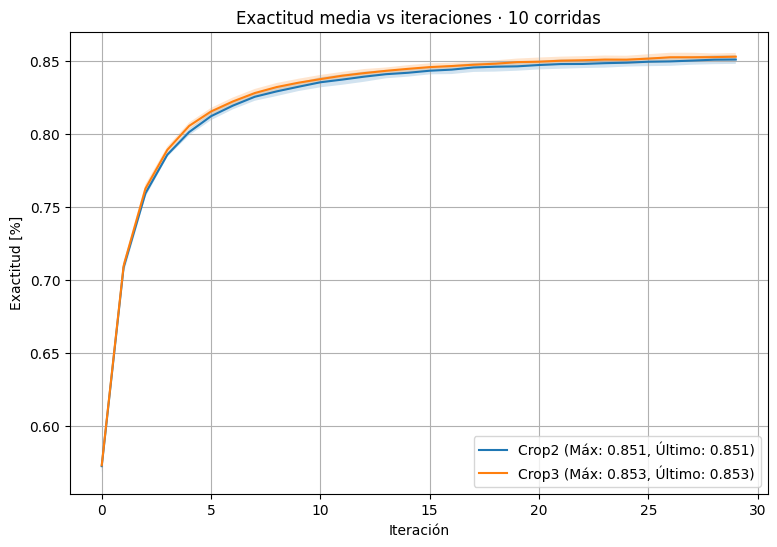

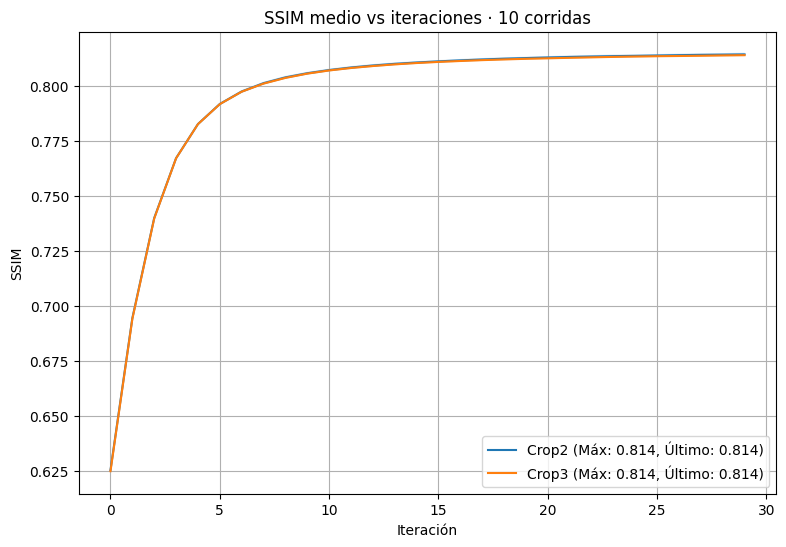

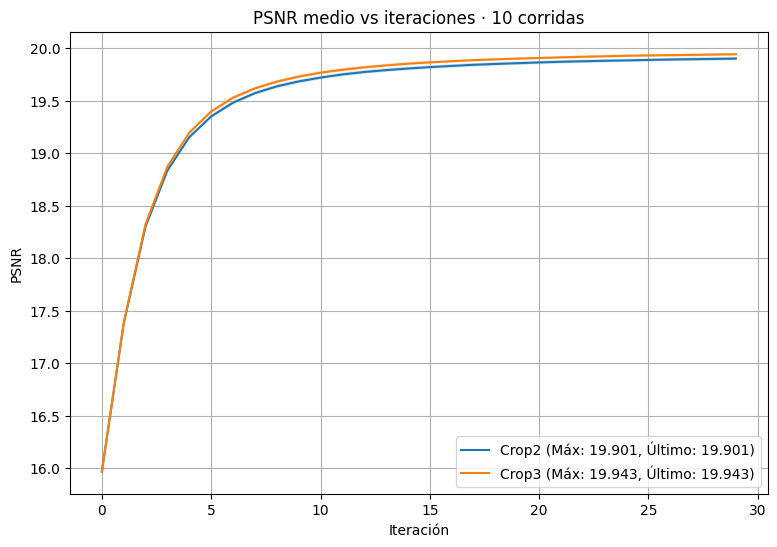

In [18]:
plt.figure(figsize=(9, 6))

for name, results in {
    "Crop2": results_crop2,
    "Crop3": results_crop3
}.items():

    acc = results["mean_acc"]
    std = results["std_acc"]

    x = np.arange(len(acc))

    plt.plot(
        x,
        acc,
        label=f"{name} (Máx: {acc.max():.3f}, Último: {acc[-1]:.3f})"
    )

    plt.fill_between(
        x,
        acc - std,
        acc + std,
        alpha=0.2
    )

plt.grid()
plt.title(f"Exactitud media vs iteraciones · {N_RUNS} corridas")
plt.xlabel("Iteración")
plt.ylabel("Exactitud [%]")
plt.legend()
plt.show()



plt.figure(figsize=(9, 6))

for name, results in {
    "Crop2": results_crop2,
    "Crop3": results_crop3
}.items():

    ssim = results["mean_ssim"]
    std = results["std_ssim"]

    x = np.arange(len(ssim))

    plt.plot(
        x,
        ssim,
        label=f"{name} (Máx: {ssim.max():.3f}, Último: {ssim[-1]:.3f})"
    )

    plt.fill_between(
        x,
        ssim - std,
        ssim + std,
        alpha=0.2
    )

plt.grid()
plt.title(f"SSIM medio vs iteraciones · {N_RUNS} corridas")
plt.xlabel("Iteración")
plt.ylabel("SSIM")
plt.legend()
plt.show()



plt.figure(figsize=(9, 6))

for name, results in {
    "Crop2": results_crop2,
    "Crop3": results_crop3
}.items():

    psnr = results["mean_psnr"]
    std = results["std_psnr"]

    x = np.arange(len(psnr))

    plt.plot(
        x,
        psnr,
        label=f"{name} (Máx: {psnr.max():.3f}, Último: {psnr[-1]:.3f})"
    )

    plt.fill_between(
        x,
        psnr - std,
        psnr + std,
        alpha=0.2
    )

plt.grid()
plt.title(f"PSNR medio vs iteraciones · {N_RUNS} corridas")
plt.xlabel("Iteración")
plt.ylabel("PSNR")
plt.legend()
plt.show()